<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 2 - Fine-tuning a Pretrained Model

**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

In this notebook, a classification model is fine-tuned given a previous pretrained one. The model uses the dataset [Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) and the data split analised in the previous notebook([00_data_exploration.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb) and [01_task1_scratch.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch.ipynb)). The tuning is performed independantly over different fractions of the training database (10%, 25%, 50%, 75% and 100%), and the summary of metrics and plots are shown and downloaded in a zip format.

**Observations:**
1.   the first six (6) cells of code bellow were implemented to be able to run the notebook using Google Colab mantainig it connected to the GitHub project. The rest o the code was initially wroten using DataSpell.
2.   To better estimate the uncertainty three (3) notebook in total, were ran with distinct random seed. The other two notebooks are avalible at: [02_task2_finetune_2.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune_2.ipynb) and [02_task2_finetune_3.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune_3.ipynb).

In [ ]:
!rm -rf /content/TOL506M_Final_Project

In [ ]:
import os, sys, subprocess, pathlib

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [ ]:
import sys
import os
import subprocess
import importlib
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter
from PIL import Image
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.8.0+cu126
CUDA available: True


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [ ]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          compute_class_counts, materialize_split, is_italian,
                          translate_names, get_class_names, get_data_loaders)
from data.augmentation import get_train_transforms, get_val_transforms
from models.resnet_scratch import ResNet18Scratch
from tasks.task2 import fine_tune_pretrained
from utils.training import train_epoch, validate, EarlyStopping
from utils.evaluation import evaluate_model, get_confusion_matrix, compute_metrics
from utils.visualization import plot_training_curves, plot_confusion_matrix

data_fractions = Config.DATA_FRACTION
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on previous notebooks
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=random_seed
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [ ]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)


Starting traning with freezing mode all_but_fc

Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.24it/s]



 Epoch 1/50:
 Train Loss: 1.7112, Train Accuracy: 46.07%
 Val Loss: 1.0150, Val Accuracy: 70.56%
Saved best model (Val Acc: 70.56%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.87it/s]



 Epoch 2/50:
 Train Loss: 0.8385, Train Accuracy: 81.33%
 Val Loss: 0.5673, Val Accuracy: 88.49%
Saved best model (Val Acc: 88.49%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.25it/s]



 Epoch 49/50:
 Train Loss: 0.1563, Train Accuracy: 95.58%
 Val Loss: 0.2099, Val Accuracy: 93.76%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.08it/s]


 Epoch 50/50:
 Train Loss: 0.1578, Train Accuracy: 96.07%
 Val Loss: 0.2068, Val Accuracy: 93.63%
Training completed in 478.51 seconds.



 Test Results: 
 Accuracy: 94.07%
 Precision: 94.21%
 Recall: 94.07%
 F1-score: 94.07%


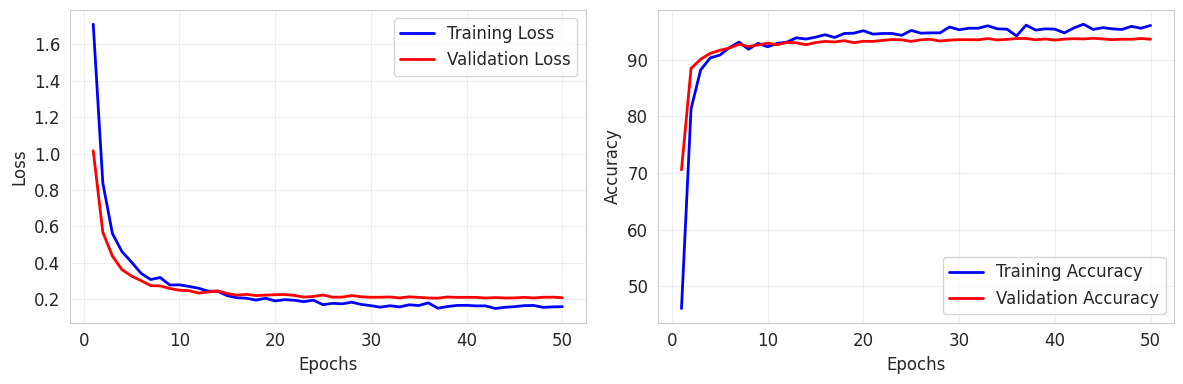


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.42it/s]



 Epoch 1/50:
 Train Loss: 1.1189, Train Accuracy: 69.77%
 Val Loss: 0.4615, Val Accuracy: 89.79%
Saved best model (Val Acc: 89.79%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.59it/s]



 Epoch 2/50:
 Train Loss: 0.4439, Train Accuracy: 89.50%
 Val Loss: 0.3002, Val Accuracy: 92.67%
Saved best model (Val Acc: 92.67%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.20it/s]



 Epoch 40/50:
 Train Loss: 0.1451, Train Accuracy: 95.22%
 Val Loss: 0.1725, Val Accuracy: 94.68%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.06it/s]


 Epoch 41/50:
 Train Loss: 0.1561, Train Accuracy: 94.39%
 Val Loss: 0.1698, Val Accuracy: 94.78%
Early stopping triggered at epoch 41.
Training completed in 668.36 seconds.



 Test Results: 
 Accuracy: 95.03%
 Precision: 95.07%
 Recall: 95.03%
 F1-score: 95.02%


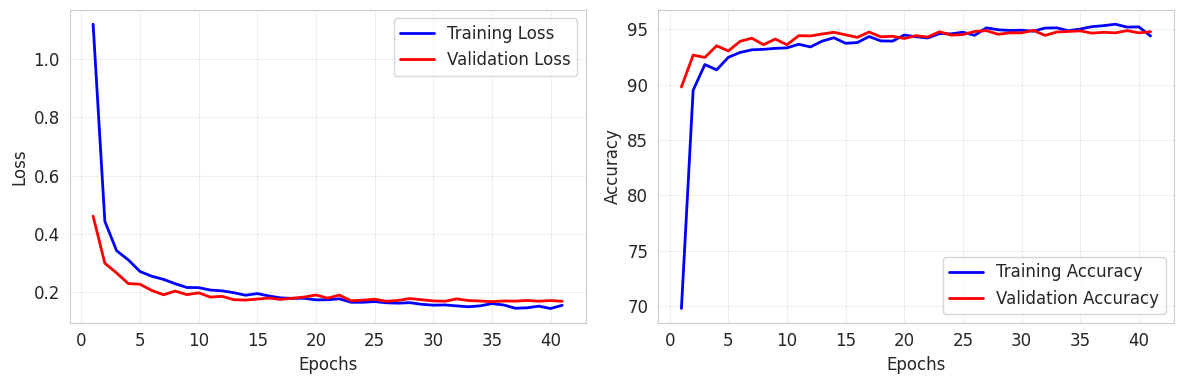


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.04it/s]



 Epoch 1/50:
 Train Loss: 0.8120, Train Accuracy: 79.00%
 Val Loss: 0.3117, Val Accuracy: 92.18%
Saved best model (Val Acc: 92.18%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.27it/s]



 Epoch 2/50:
 Train Loss: 0.3388, Train Accuracy: 90.92%
 Val Loss: 0.2321, Val Accuracy: 93.51%
Saved best model (Val Acc: 93.51%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.41it/s]



 Epoch 22/50:
 Train Loss: 0.1734, Train Accuracy: 94.55%
 Val Loss: 0.1690, Val Accuracy: 94.78%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.03it/s]


 Epoch 23/50:
 Train Loss: 0.1712, Train Accuracy: 94.37%
 Val Loss: 0.1674, Val Accuracy: 94.96%
Early stopping triggered at epoch 23.
Training completed in 644.29 seconds.



 Test Results: 
 Accuracy: 95.21%
 Precision: 95.24%
 Recall: 95.21%
 F1-score: 95.19%


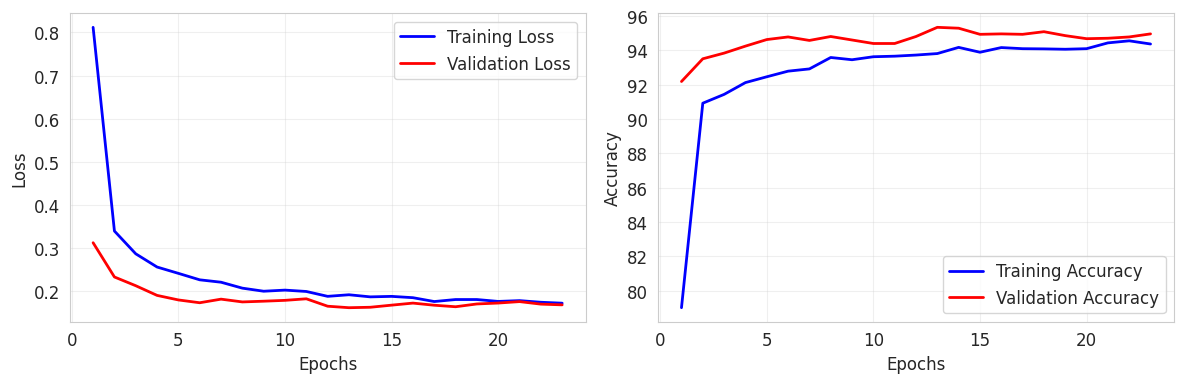


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.61it/s]



 Epoch 1/50:
 Train Loss: 0.6646, Train Accuracy: 82.37%
 Val Loss: 0.2675, Val Accuracy: 92.62%
Saved best model (Val Acc: 92.62%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.38it/s]



 Epoch 2/50:
 Train Loss: 0.2915, Train Accuracy: 91.86%
 Val Loss: 0.2007, Val Accuracy: 94.27%
Saved best model (Val Acc: 94.27%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.30it/s]



 Epoch 33/50:
 Train Loss: 0.1647, Train Accuracy: 94.46%
 Val Loss: 0.1541, Val Accuracy: 95.42%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.46it/s]


 Epoch 34/50:
 Train Loss: 0.1621, Train Accuracy: 94.75%
 Val Loss: 0.1520, Val Accuracy: 95.54%
Early stopping triggered at epoch 34.
Training completed in 1330.43 seconds.



 Test Results: 
 Accuracy: 95.65%
 Precision: 95.67%
 Recall: 95.65%
 F1-score: 95.63%


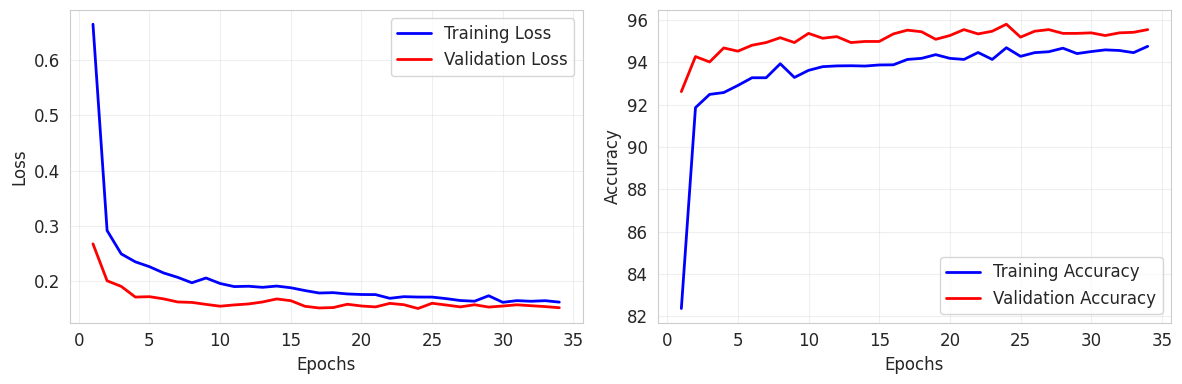


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.08it/s]



 Epoch 1/50:
 Train Loss: 0.5892, Train Accuracy: 84.32%
 Val Loss: 0.2345, Val Accuracy: 93.48%
Saved best model (Val Acc: 93.48%).


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.38it/s]



 Epoch 2/50:
 Train Loss: 0.2713, Train Accuracy: 91.96%
 Val Loss: 0.1851, Val Accuracy: 94.73%
Saved best model (Val Acc: 94.73%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.11it/s]



 Epoch 26/50:
 Train Loss: 0.1695, Train Accuracy: 94.43%
 Val Loss: 0.1516, Val Accuracy: 95.47%


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.67it/s]


 Epoch 27/50:
 Train Loss: 0.1704, Train Accuracy: 94.31%
 Val Loss: 0.1488, Val Accuracy: 95.42%
Early stopping triggered at epoch 27.
Training completed in 1369.04 seconds.



 Test Results: 
 Accuracy: 95.90%
 Precision: 95.92%
 Recall: 95.90%
 F1-score: 95.89%


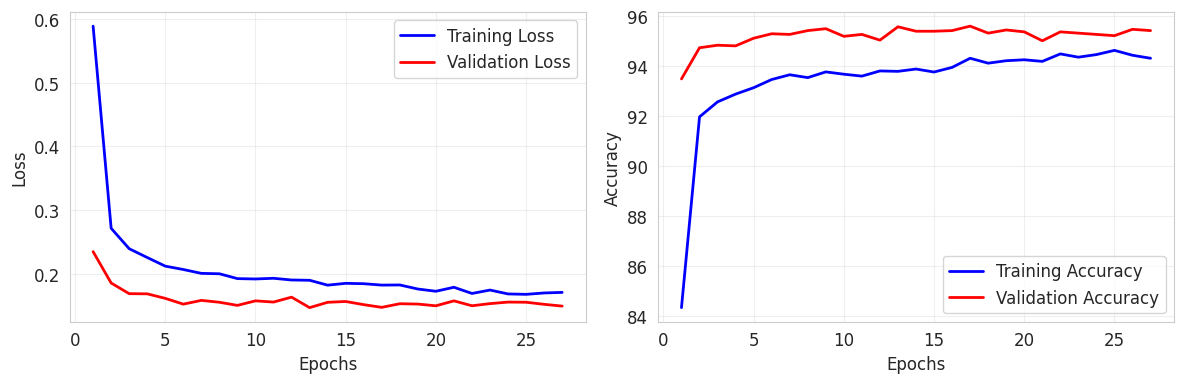


Finished training for all fractions for freezing mode all_but_fc.

Starting traning with freezing mode up_to_layer1

Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.65it/s]



 Epoch 1/50:
 Train Loss: 0.8199, Train Accuracy: 73.85%
 Val Loss: 2.2407, Val Accuracy: 57.91%
Saved best model (Val Acc: 57.91%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.12it/s]



 Epoch 2/50:
 Train Loss: 0.4595, Train Accuracy: 84.61%
 Val Loss: 0.8496, Val Accuracy: 73.77%
Saved best model (Val Acc: 73.77%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.31it/s]



 Epoch 49/50:
 Train Loss: 0.0023, Train Accuracy: 100.00%
 Val Loss: 0.4395, Val Accuracy: 88.97%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.63it/s]


 Epoch 50/50:
 Train Loss: 0.0011, Train Accuracy: 100.00%
 Val Loss: 0.4325, Val Accuracy: 89.18%
Saved best model (Val Acc: 89.18%).
Training completed in 481.28 seconds.



 Test Results: 
 Accuracy: 89.20%
 Precision: 89.25%
 Recall: 89.20%
 F1-score: 89.12%


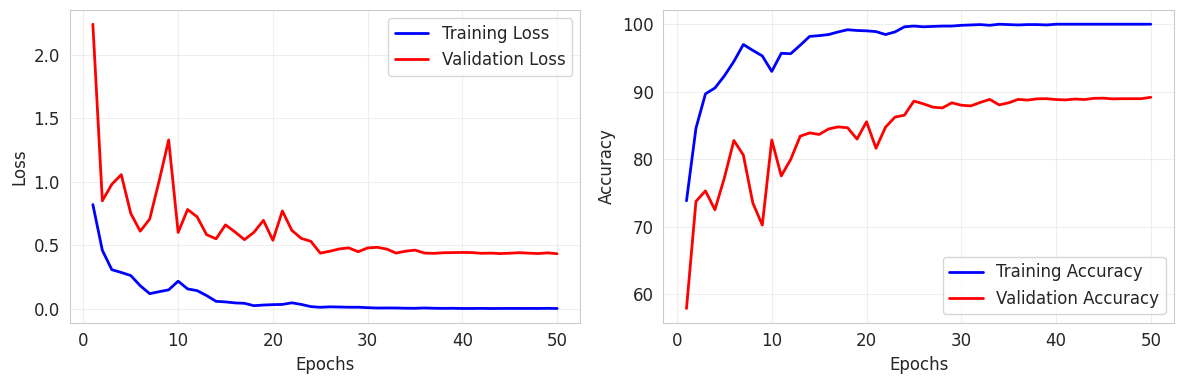


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.82it/s]



 Epoch 1/50:
 Train Loss: 0.7052, Train Accuracy: 76.77%
 Val Loss: 0.5559, Val Accuracy: 82.38%
Saved best model (Val Acc: 82.38%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.89it/s]



 Epoch 2/50:
 Train Loss: 0.3975, Train Accuracy: 86.73%
 Val Loss: 0.5957, Val Accuracy: 81.08%


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.82it/s]



 Epoch 49/50:
 Train Loss: 0.0020, Train Accuracy: 100.00%
 Val Loss: 0.2900, Val Accuracy: 92.44%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.48it/s]


 Epoch 50/50:
 Train Loss: 0.0021, Train Accuracy: 99.93%
 Val Loss: 0.2924, Val Accuracy: 92.46%
Training completed in 829.96 seconds.



 Test Results: 
 Accuracy: 92.72%
 Precision: 92.75%
 Recall: 92.72%
 F1-score: 92.70%


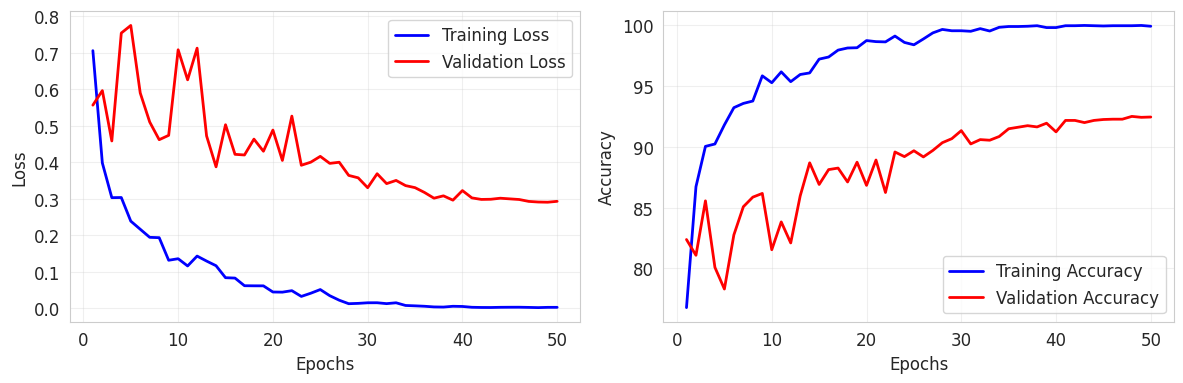


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.79it/s]



 Epoch 1/50:
 Train Loss: 0.5909, Train Accuracy: 80.87%
 Val Loss: 0.8533, Val Accuracy: 74.66%
Saved best model (Val Acc: 74.66%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.96it/s]



 Epoch 2/50:
 Train Loss: 0.3983, Train Accuracy: 87.37%
 Val Loss: 0.6842, Val Accuracy: 79.37%
Saved best model (Val Acc: 79.37%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.35it/s]



 Epoch 23/50:
 Train Loss: 0.0557, Train Accuracy: 98.34%
 Val Loss: 0.3295, Val Accuracy: 90.25%


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.86it/s]


 Epoch 24/50:
 Train Loss: 0.0865, Train Accuracy: 97.16%
 Val Loss: 0.3243, Val Accuracy: 90.35%
Early stopping triggered at epoch 24.
Training completed in 675.97 seconds.



 Test Results: 
 Accuracy: 90.09%
 Precision: 90.24%
 Recall: 90.09%
 F1-score: 90.03%


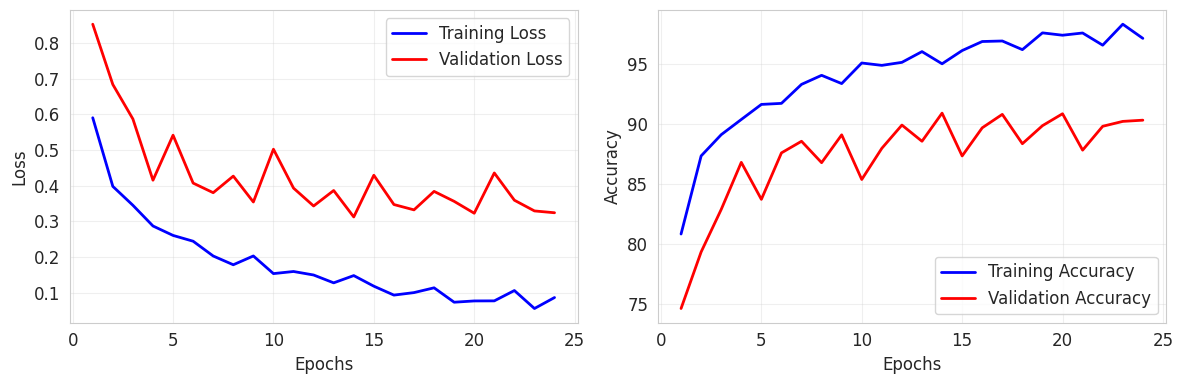


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.29it/s]



 Epoch 1/50:
 Train Loss: 0.5482, Train Accuracy: 82.11%
 Val Loss: 0.5953, Val Accuracy: 81.33%
Saved best model (Val Acc: 81.33%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.46it/s]



 Epoch 2/50:
 Train Loss: 0.3505, Train Accuracy: 88.87%
 Val Loss: 0.4935, Val Accuracy: 84.62%
Saved best model (Val Acc: 84.62%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.42it/s]



 Epoch 17/50:
 Train Loss: 0.1105, Train Accuracy: 96.35%
 Val Loss: 0.2790, Val Accuracy: 91.19%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.14it/s]


 Epoch 18/50:
 Train Loss: 0.1020, Train Accuracy: 96.76%
 Val Loss: 0.3788, Val Accuracy: 89.20%
Early stopping triggered at epoch 18.
Training completed in 709.74 seconds.



 Test Results: 
 Accuracy: 89.48%
 Precision: 90.29%
 Recall: 89.48%
 F1-score: 89.53%


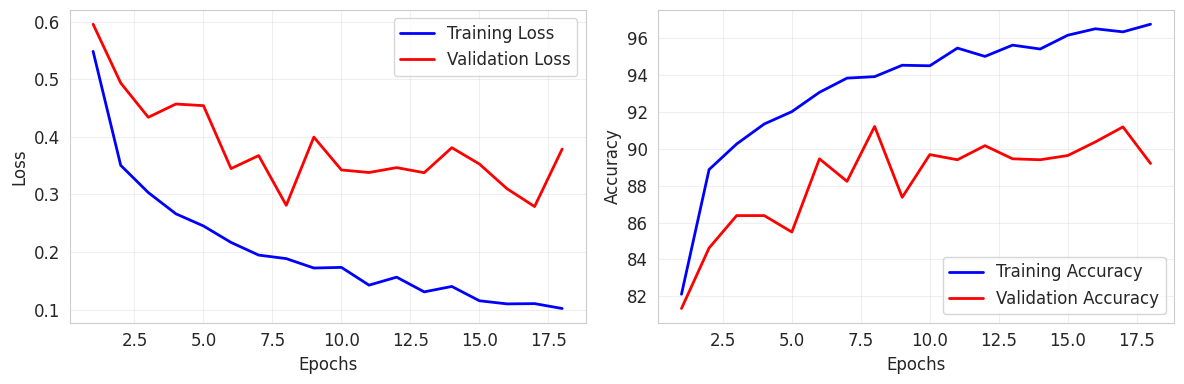


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.69it/s]



 Epoch 1/50:
 Train Loss: 0.5347, Train Accuracy: 82.76%
 Val Loss: 0.5813, Val Accuracy: 80.90%
Saved best model (Val Acc: 80.90%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.22it/s]



 Epoch 2/50:
 Train Loss: 0.3457, Train Accuracy: 88.97%
 Val Loss: 0.4188, Val Accuracy: 86.35%
Saved best model (Val Acc: 86.35%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.74it/s]



 Epoch 49/50:
 Train Loss: 0.0036, Train Accuracy: 99.92%
 Val Loss: 0.2122, Val Accuracy: 94.50%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.17it/s]


 Epoch 50/50:
 Train Loss: 0.0040, Train Accuracy: 99.91%
 Val Loss: 0.2075, Val Accuracy: 94.68%
Saved best model (Val Acc: 94.68%).
Training completed in 2543.28 seconds.



 Test Results: 
 Accuracy: 94.81%
 Precision: 94.83%
 Recall: 94.81%
 F1-score: 94.79%


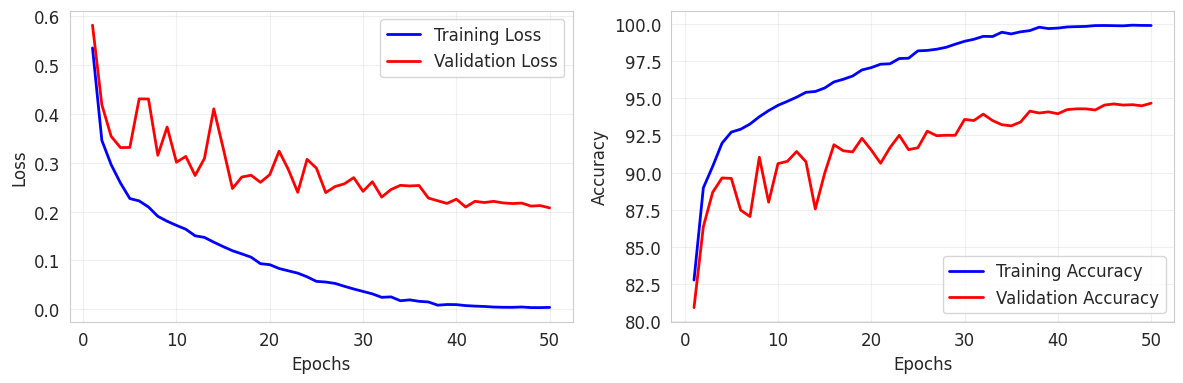


Finished training for all fractions for freezing mode up_to_layer1.

Starting traning with freezing mode up_to_layer2

Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.27it/s]



 Epoch 1/50:
 Train Loss: 0.7127, Train Accuracy: 75.98%
 Val Loss: 1.0209, Val Accuracy: 74.33%
Saved best model (Val Acc: 74.33%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.97it/s]



 Epoch 2/50:
 Train Loss: 0.3861, Train Accuracy: 86.63%
 Val Loss: 0.6199, Val Accuracy: 80.95%
Saved best model (Val Acc: 80.95%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.98it/s]



 Epoch 49/50:
 Train Loss: 0.0017, Train Accuracy: 99.95%
 Val Loss: 0.3892, Val Accuracy: 90.12%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.01it/s]


 Epoch 50/50:
 Train Loss: 0.0014, Train Accuracy: 100.00%
 Val Loss: 0.3891, Val Accuracy: 89.97%
Early stopping triggered at epoch 50.
Training completed in 485.19 seconds.



 Test Results: 
 Accuracy: 90.68%
 Precision: 90.80%
 Recall: 90.68%
 F1-score: 90.65%


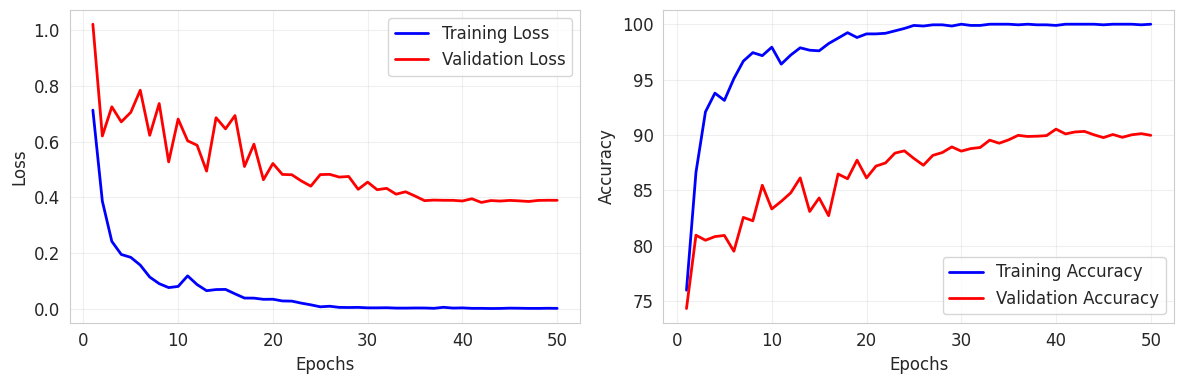


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.23it/s]



 Epoch 1/50:
 Train Loss: 0.6158, Train Accuracy: 79.92%
 Val Loss: 0.6864, Val Accuracy: 78.86%
Saved best model (Val Acc: 78.86%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.57it/s]



 Epoch 2/50:
 Train Loss: 0.3258, Train Accuracy: 89.06%
 Val Loss: 0.7587, Val Accuracy: 78.61%


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.82it/s]



 Epoch 49/50:
 Train Loss: 0.0019, Train Accuracy: 99.98%
 Val Loss: 0.2514, Val Accuracy: 93.96%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.00it/s]


 Epoch 50/50:
 Train Loss: 0.0023, Train Accuracy: 99.93%
 Val Loss: 0.2526, Val Accuracy: 94.02%
Training completed in 832.33 seconds.



 Test Results: 
 Accuracy: 93.63%
 Precision: 93.63%
 Recall: 93.63%
 F1-score: 93.61%


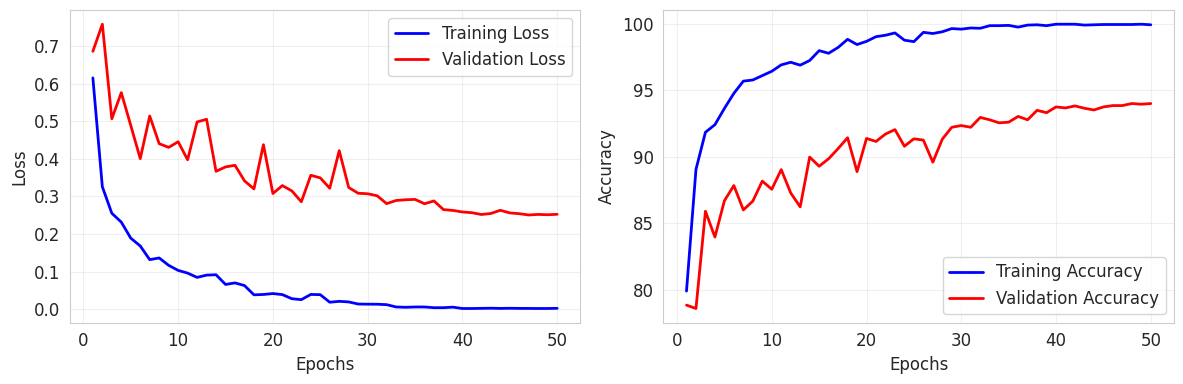


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.16it/s]



 Epoch 1/50:
 Train Loss: 0.5067, Train Accuracy: 83.85%
 Val Loss: 0.4877, Val Accuracy: 85.00%
Saved best model (Val Acc: 85.00%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.97it/s]



 Epoch 2/50:
 Train Loss: 0.3331, Train Accuracy: 89.28%
 Val Loss: 0.3587, Val Accuracy: 88.54%
Saved best model (Val Acc: 88.54%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.05it/s]



 Epoch 21/50:
 Train Loss: 0.0632, Train Accuracy: 98.24%
 Val Loss: 0.2625, Val Accuracy: 92.28%


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.63it/s]


 Epoch 22/50:
 Train Loss: 0.0518, Train Accuracy: 98.50%
 Val Loss: 0.2993, Val Accuracy: 91.29%
Early stopping triggered at epoch 22.
Training completed in 632.39 seconds.



 Test Results: 
 Accuracy: 90.83%
 Precision: 91.33%
 Recall: 90.83%
 F1-score: 90.83%


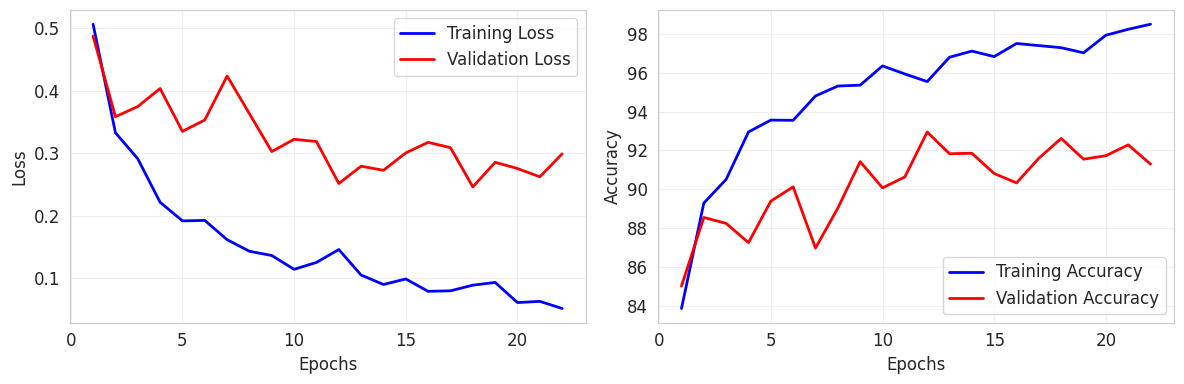


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.55it/s]



 Epoch 1/50:
 Train Loss: 0.4646, Train Accuracy: 85.05%
 Val Loss: 0.5206, Val Accuracy: 84.39%
Saved best model (Val Acc: 84.39%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.89it/s]



 Epoch 2/50:
 Train Loss: 0.2860, Train Accuracy: 90.85%
 Val Loss: 0.3710, Val Accuracy: 87.73%
Saved best model (Val Acc: 87.73%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.61it/s]



 Epoch 17/50:
 Train Loss: 0.0847, Train Accuracy: 97.26%
 Val Loss: 0.2675, Val Accuracy: 91.60%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.44it/s]


 Epoch 18/50:
 Train Loss: 0.0770, Train Accuracy: 97.49%
 Val Loss: 0.2548, Val Accuracy: 92.74%
Early stopping triggered at epoch 18.
Training completed in 716.83 seconds.



 Test Results: 
 Accuracy: 92.44%
 Precision: 92.78%
 Recall: 92.44%
 F1-score: 92.39%


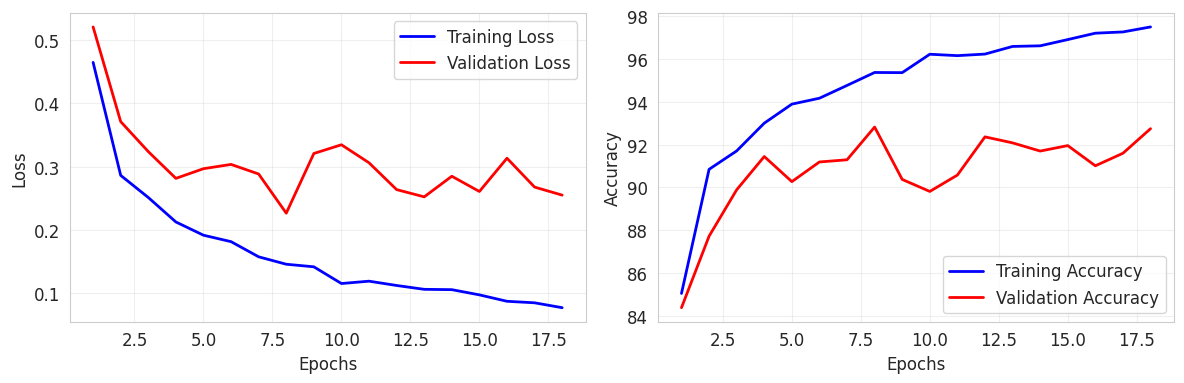


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.06it/s]



 Epoch 1/50:
 Train Loss: 0.4538, Train Accuracy: 85.82%
 Val Loss: 0.4941, Val Accuracy: 84.82%
Saved best model (Val Acc: 84.82%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.05it/s]



 Epoch 2/50:
 Train Loss: 0.2871, Train Accuracy: 90.63%
 Val Loss: 0.2922, Val Accuracy: 90.55%
Saved best model (Val Acc: 90.55%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.89it/s]



 Epoch 49/50:
 Train Loss: 0.0046, Train Accuracy: 99.90%
 Val Loss: 0.1879, Val Accuracy: 95.52%
Saved best model (Val Acc: 95.52%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.99it/s]


 Epoch 50/50:
 Train Loss: 0.0036, Train Accuracy: 99.90%
 Val Loss: 0.1836, Val Accuracy: 95.29%
Training completed in 2545.43 seconds.



 Test Results: 
 Accuracy: 95.72%
 Precision: 95.74%
 Recall: 95.72%
 F1-score: 95.72%


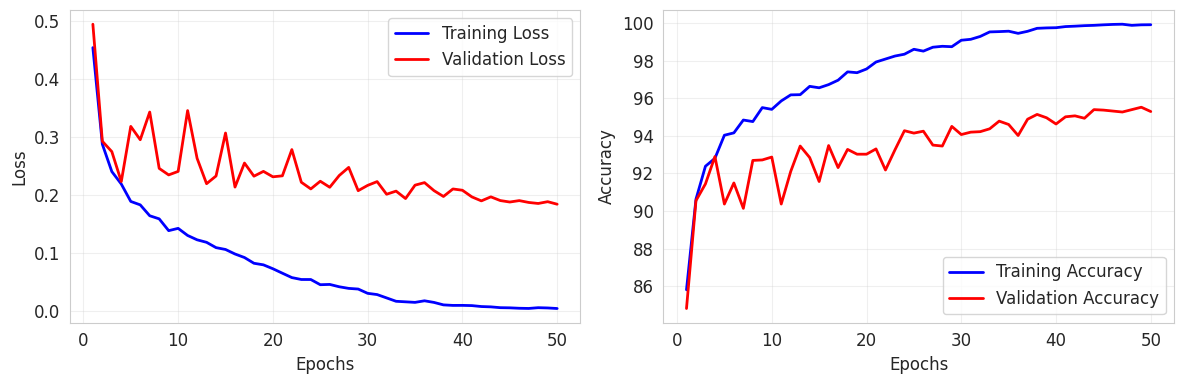


Finished training for all fractions for freezing mode up_to_layer2.

Starting traning with freezing mode up_to_layer3

Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.82it/s]



 Epoch 1/50:
 Train Loss: 0.5953, Train Accuracy: 80.46%
 Val Loss: 0.6756, Val Accuracy: 81.64%
Saved best model (Val Acc: 81.64%).


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.33it/s]



 Epoch 2/50:
 Train Loss: 0.2566, Train Accuracy: 90.67%
 Val Loss: 0.3517, Val Accuracy: 89.87%
Saved best model (Val Acc: 89.87%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.86it/s]



 Epoch 14/50:
 Train Loss: 0.0322, Train Accuracy: 99.07%
 Val Loss: 0.3614, Val Accuracy: 90.15%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.34it/s]


 Epoch 15/50:
 Train Loss: 0.0187, Train Accuracy: 99.73%
 Val Loss: 0.4186, Val Accuracy: 89.23%
Early stopping triggered at epoch 15.
Training completed in 145.30 seconds.



 Test Results: 
 Accuracy: 90.02%
 Precision: 90.17%
 Recall: 90.02%
 F1-score: 89.96%


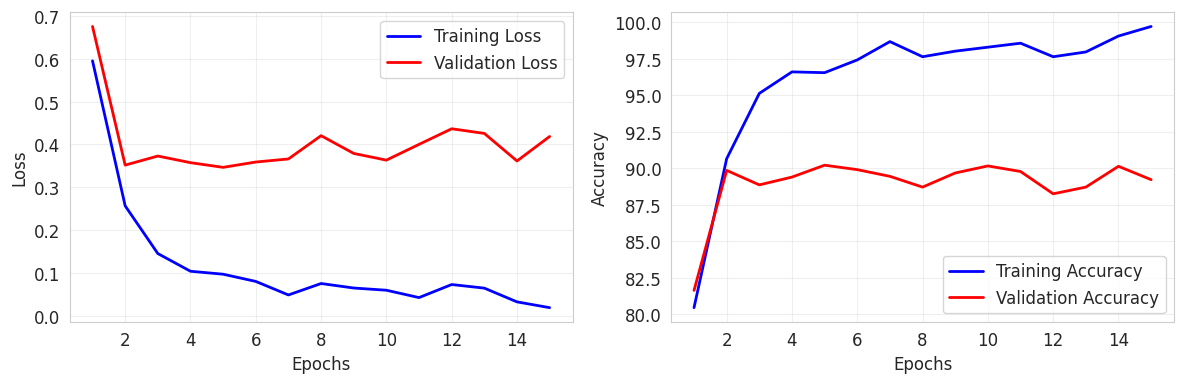


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.74it/s]



 Epoch 1/50:
 Train Loss: 0.4481, Train Accuracy: 85.48%
 Val Loss: 0.3319, Val Accuracy: 89.05%
Saved best model (Val Acc: 89.05%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.67it/s]



 Epoch 2/50:
 Train Loss: 0.2242, Train Accuracy: 92.43%
 Val Loss: 0.2609, Val Accuracy: 91.65%
Saved best model (Val Acc: 91.65%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.02it/s]



 Epoch 49/50:
 Train Loss: 0.0018, Train Accuracy: 100.00%
 Val Loss: 0.2006, Val Accuracy: 94.65%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.28it/s]


 Epoch 50/50:
 Train Loss: 0.0018, Train Accuracy: 99.96%
 Val Loss: 0.2031, Val Accuracy: 94.55%
Training completed in 826.29 seconds.



 Test Results: 
 Accuracy: 94.98%
 Precision: 94.98%
 Recall: 94.98%
 F1-score: 94.97%


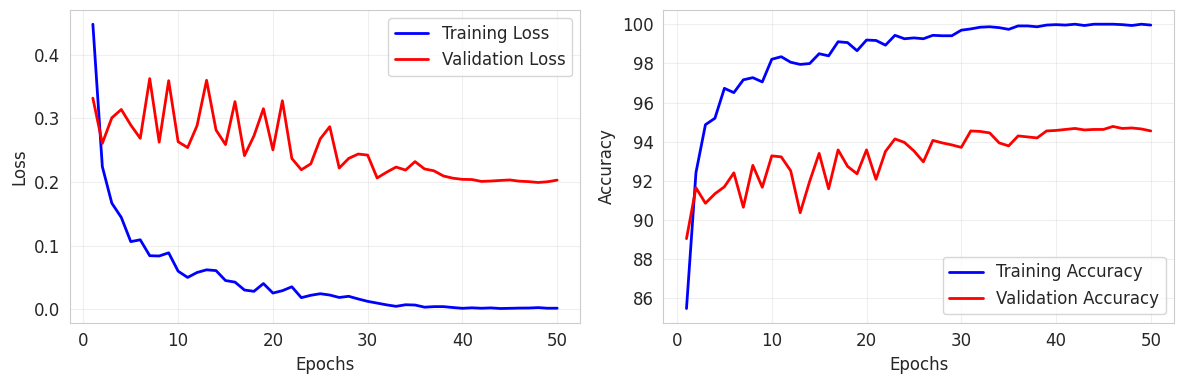


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:04<00:00, 12.64it/s]



 Epoch 1/50:
 Train Loss: 0.3855, Train Accuracy: 87.54%
 Val Loss: 0.2421, Val Accuracy: 92.28%
Saved best model (Val Acc: 92.28%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.04it/s]



 Epoch 2/50:
 Train Loss: 0.2310, Train Accuracy: 92.46%
 Val Loss: 0.2388, Val Accuracy: 92.82%
Saved best model (Val Acc: 92.82%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.83it/s]



 Epoch 22/50:
 Train Loss: 0.0556, Train Accuracy: 98.22%
 Val Loss: 0.2481, Val Accuracy: 93.81%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.49it/s]


 Epoch 23/50:
 Train Loss: 0.0341, Train Accuracy: 98.94%
 Val Loss: 0.2174, Val Accuracy: 94.75%
Early stopping triggered at epoch 23.
Training completed in 654.15 seconds.



 Test Results: 
 Accuracy: 94.40%
 Precision: 94.51%
 Recall: 94.40%
 F1-score: 94.39%


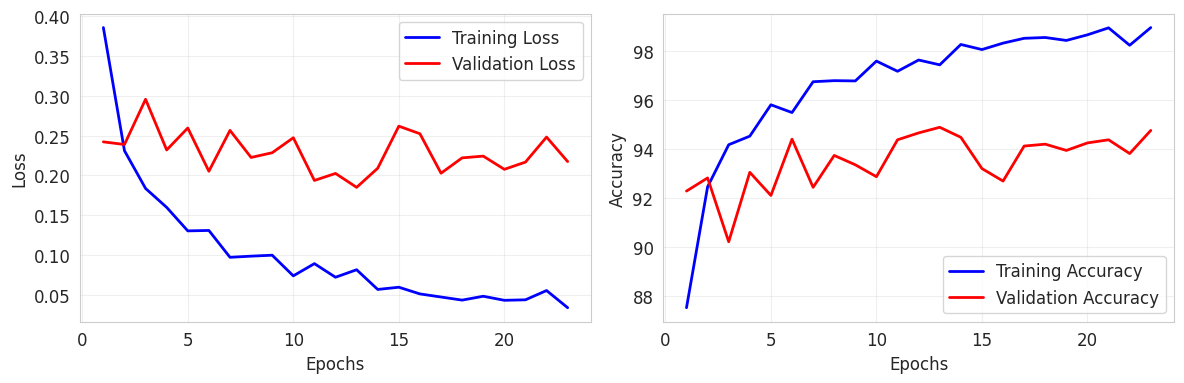


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.23it/s]



 Epoch 1/50:
 Train Loss: 0.3563, Train Accuracy: 88.41%
 Val Loss: 0.3000, Val Accuracy: 90.76%
Saved best model (Val Acc: 90.76%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.09it/s]



 Epoch 2/50:
 Train Loss: 0.2136, Train Accuracy: 93.13%
 Val Loss: 0.3589, Val Accuracy: 89.08%


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 12.57it/s]



 Epoch 49/50:
 Train Loss: 0.0026, Train Accuracy: 99.94%
 Val Loss: 0.1436, Val Accuracy: 96.41%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.27it/s]


 Epoch 50/50:
 Train Loss: 0.0030, Train Accuracy: 99.96%
 Val Loss: 0.1456, Val Accuracy: 96.36%
Training completed in 2003.29 seconds.



 Test Results: 
 Accuracy: 96.56%
 Precision: 96.58%
 Recall: 96.56%
 F1-score: 96.56%


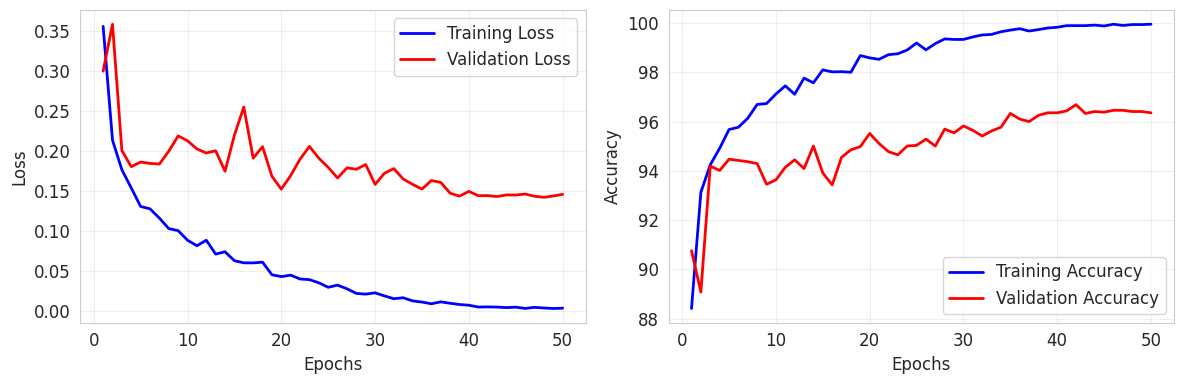


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 12.18it/s]



 Epoch 1/50:
 Train Loss: 0.3425, Train Accuracy: 88.88%
 Val Loss: 0.2149, Val Accuracy: 93.28%
Saved best model (Val Acc: 93.28%).


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.19it/s]



 Epoch 2/50:
 Train Loss: 0.2113, Train Accuracy: 93.38%
 Val Loss: 0.1934, Val Accuracy: 93.91%
Saved best model (Val Acc: 93.91%).


...

Validation: 100%|██████████| 62/62 [00:04<00:00, 13.26it/s]



 Epoch 47/50:
 Train Loss: 0.0038, Train Accuracy: 99.91%
 Val Loss: 0.1515, Val Accuracy: 96.18%


Validation: 100%|██████████| 62/62 [00:04<00:00, 13.46it/s]


 Epoch 48/50:
 Train Loss: 0.0046, Train Accuracy: 99.90%
 Val Loss: 0.1470, Val Accuracy: 96.23%
Early stopping triggered at epoch 48.
Training completed in 2453.69 seconds.



 Test Results: 
 Accuracy: 96.74%
 Precision: 96.74%
 Recall: 96.74%
 F1-score: 96.74%


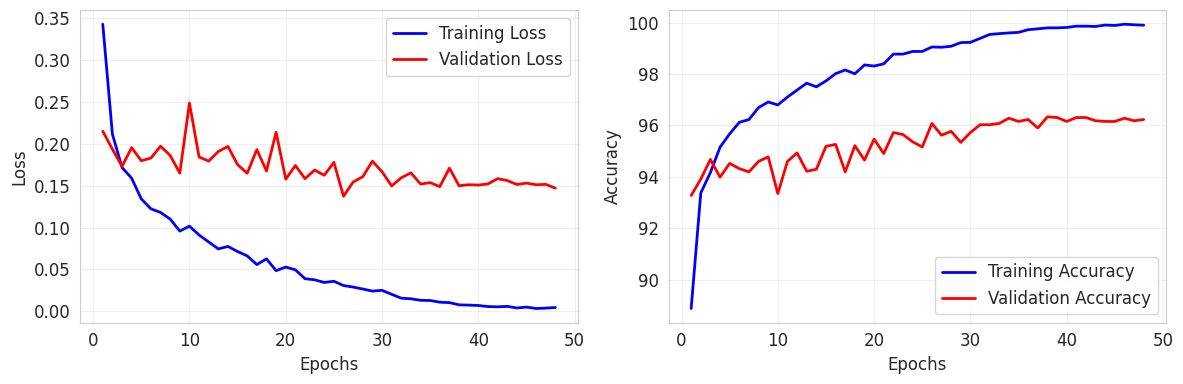


Finished training for all fractions for freezing mode up_to_layer3.

Finished training for all freezing modes


In [ ]:
# Task 2: Fine-tune a pretrained ResNet model
all_results = []

freeze_modes = Config.FREEZE_LAYERS

for freeze_mode in freeze_modes:
  print(f"\nStarting training with freezing mode {freeze_mode}\n")

  for frac in data_fractions:
    print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

    train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=Config.RANDOM_SEED,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
    )

    result = fine_tune_pretrained(
        config=Config,
        data_fraction=frac,
        save_mode=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        freeze_mode=freeze_mode
    )

    all_results.append(result)

  print(f"\nFinished training for all fractions for freeze mode {freeze_mode}.\n")

print("\nFinished training for all fractions for all freezing modes.\n")

In [ ]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / "task2_finetune_summary.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json



Learning curves of freeze mode all_but_fc and for fraction 10%


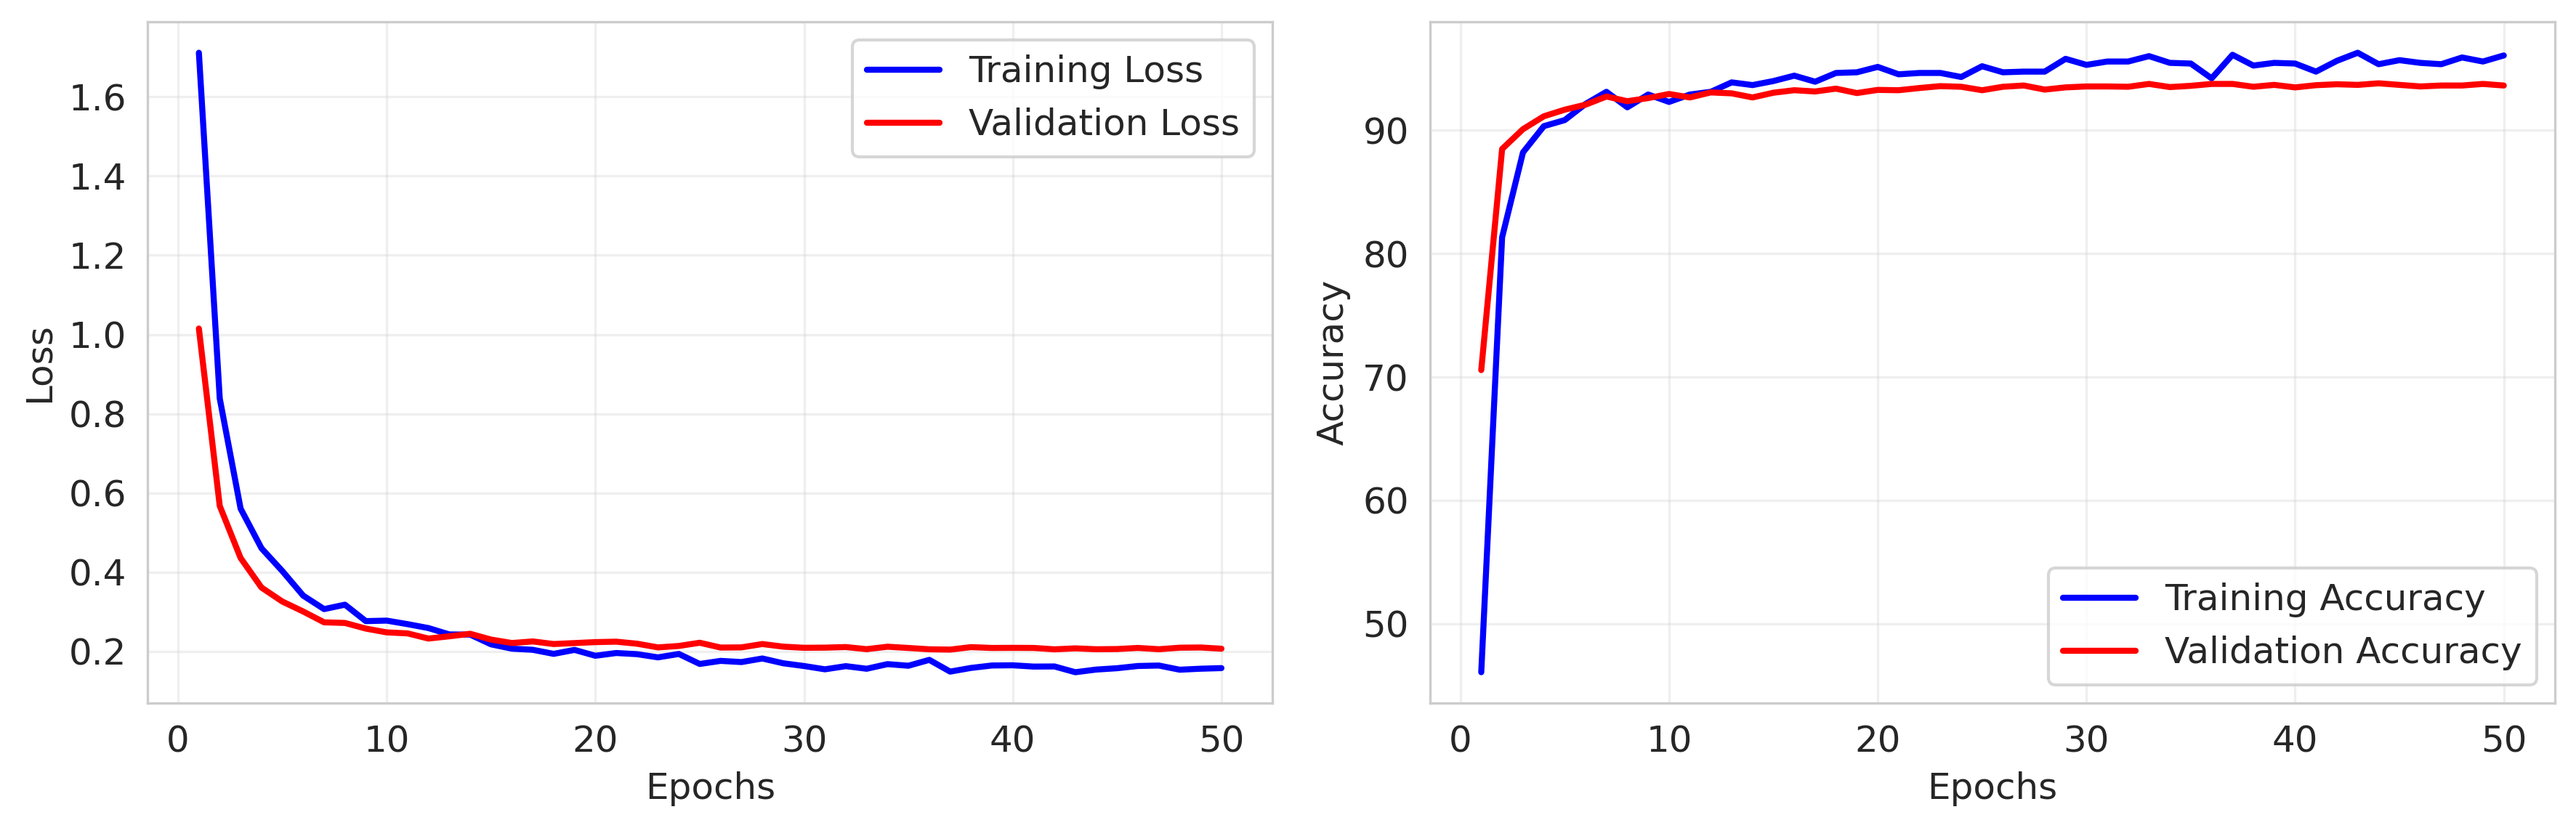


Learning curves of freeze mode all_but_fc and for fraction 25%


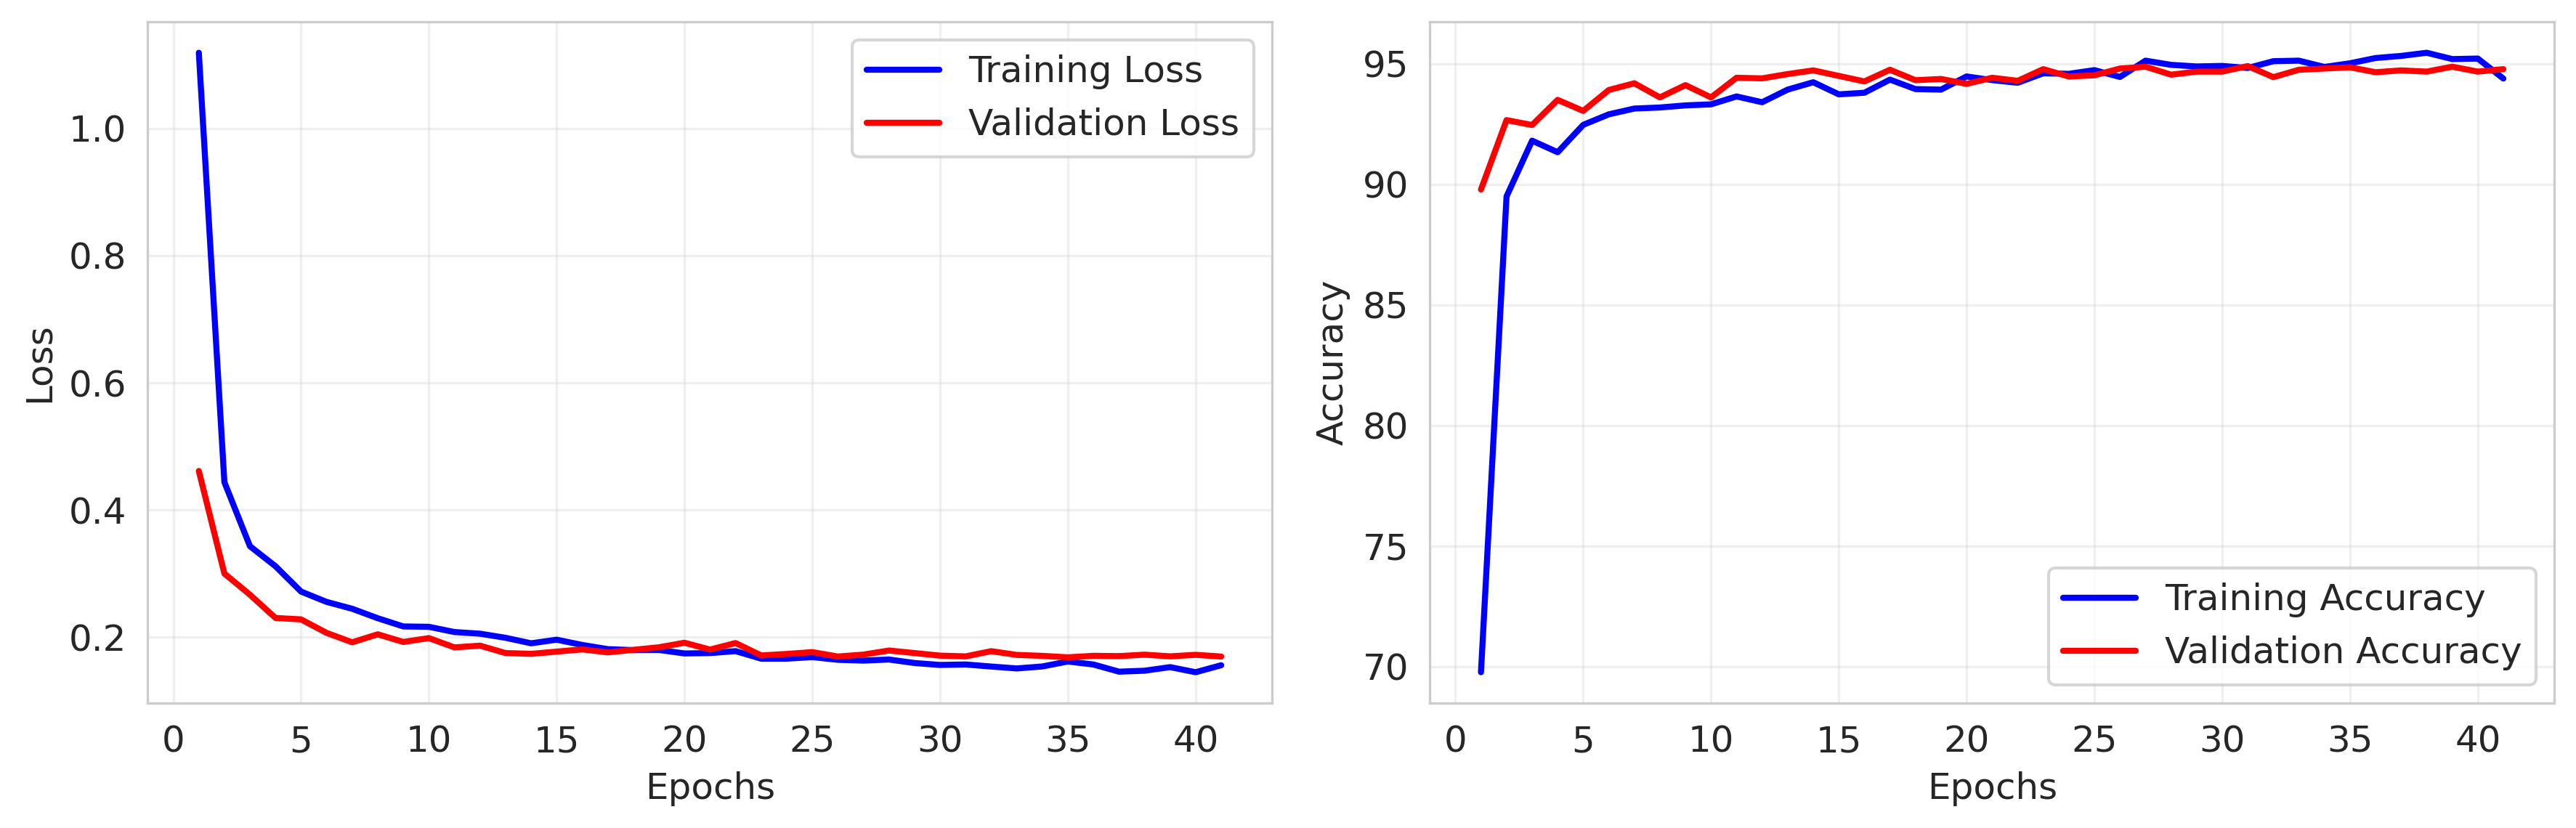


Learning curves of freeze mode all_but_fc and for fraction 50%


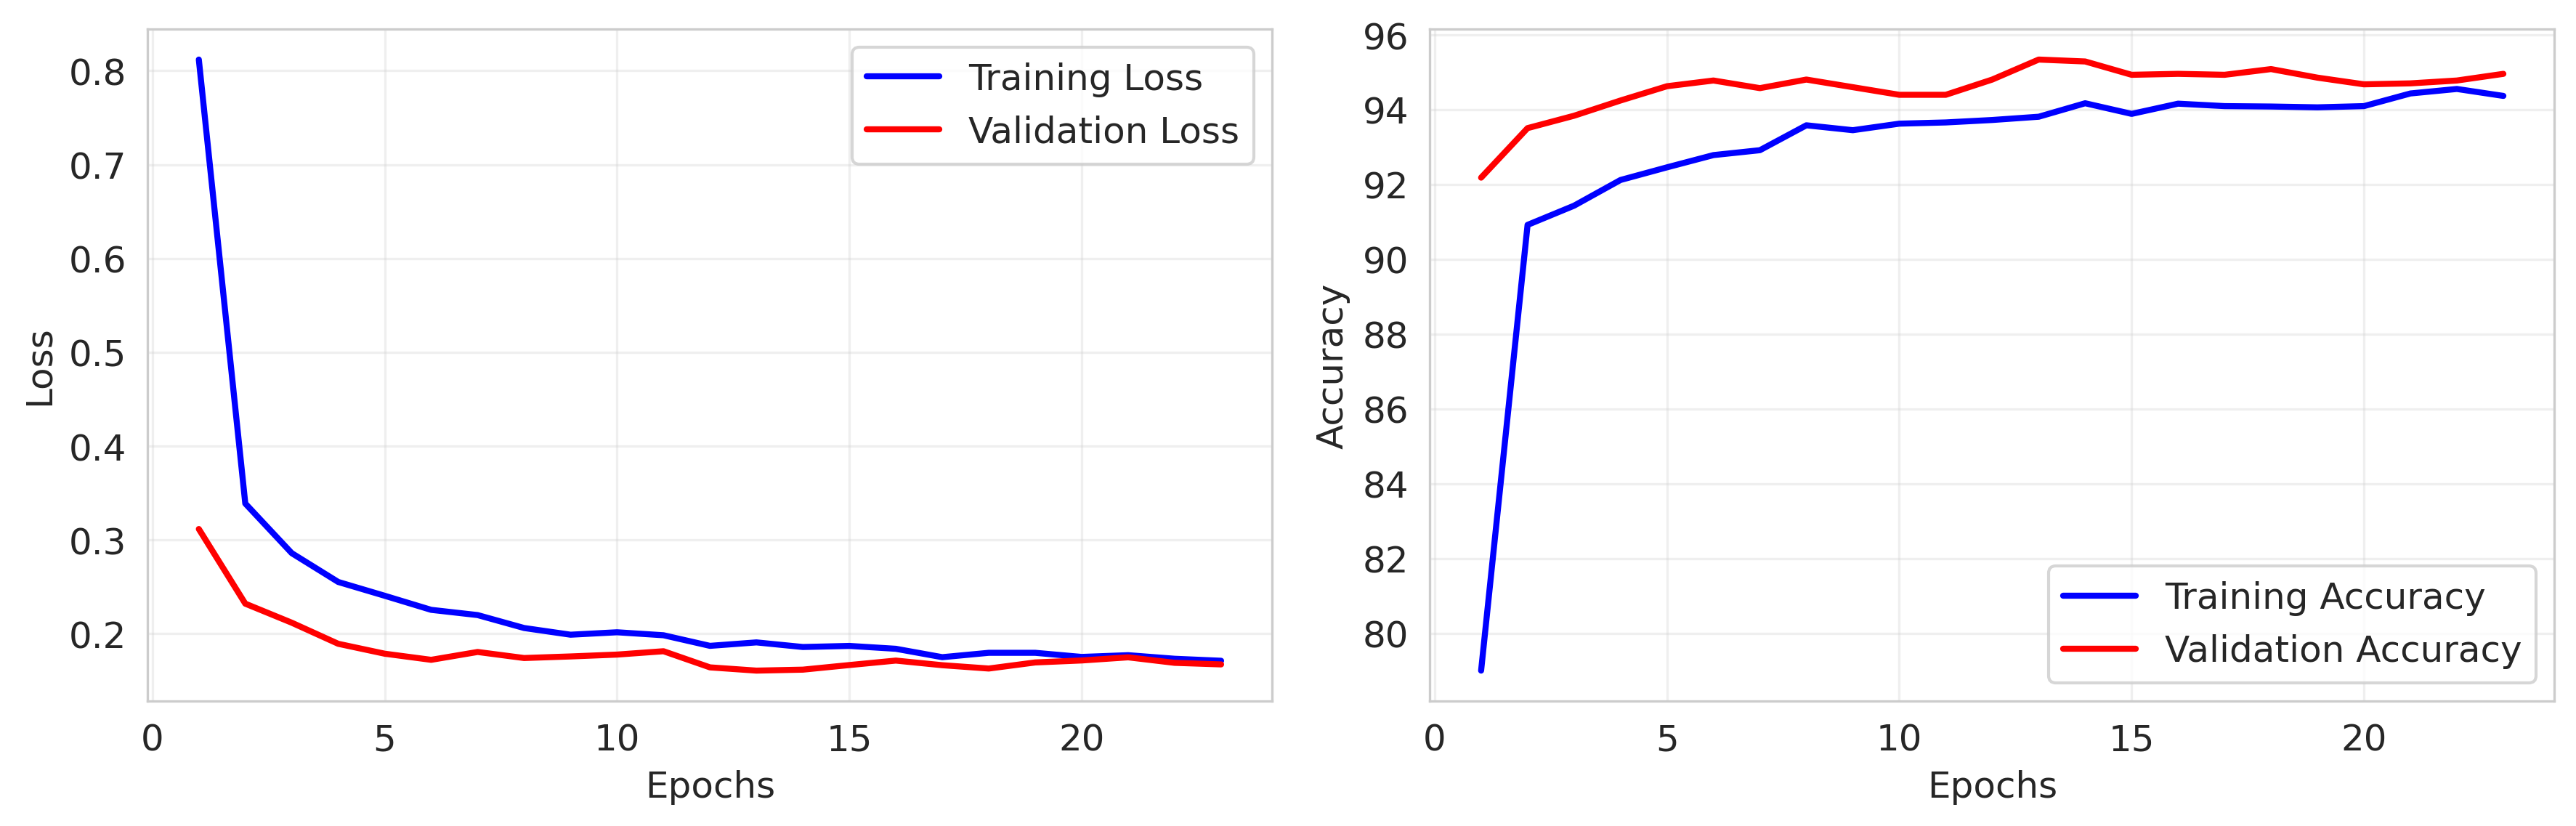


Learning curves of freeze mode all_but_fc and for fraction 75%


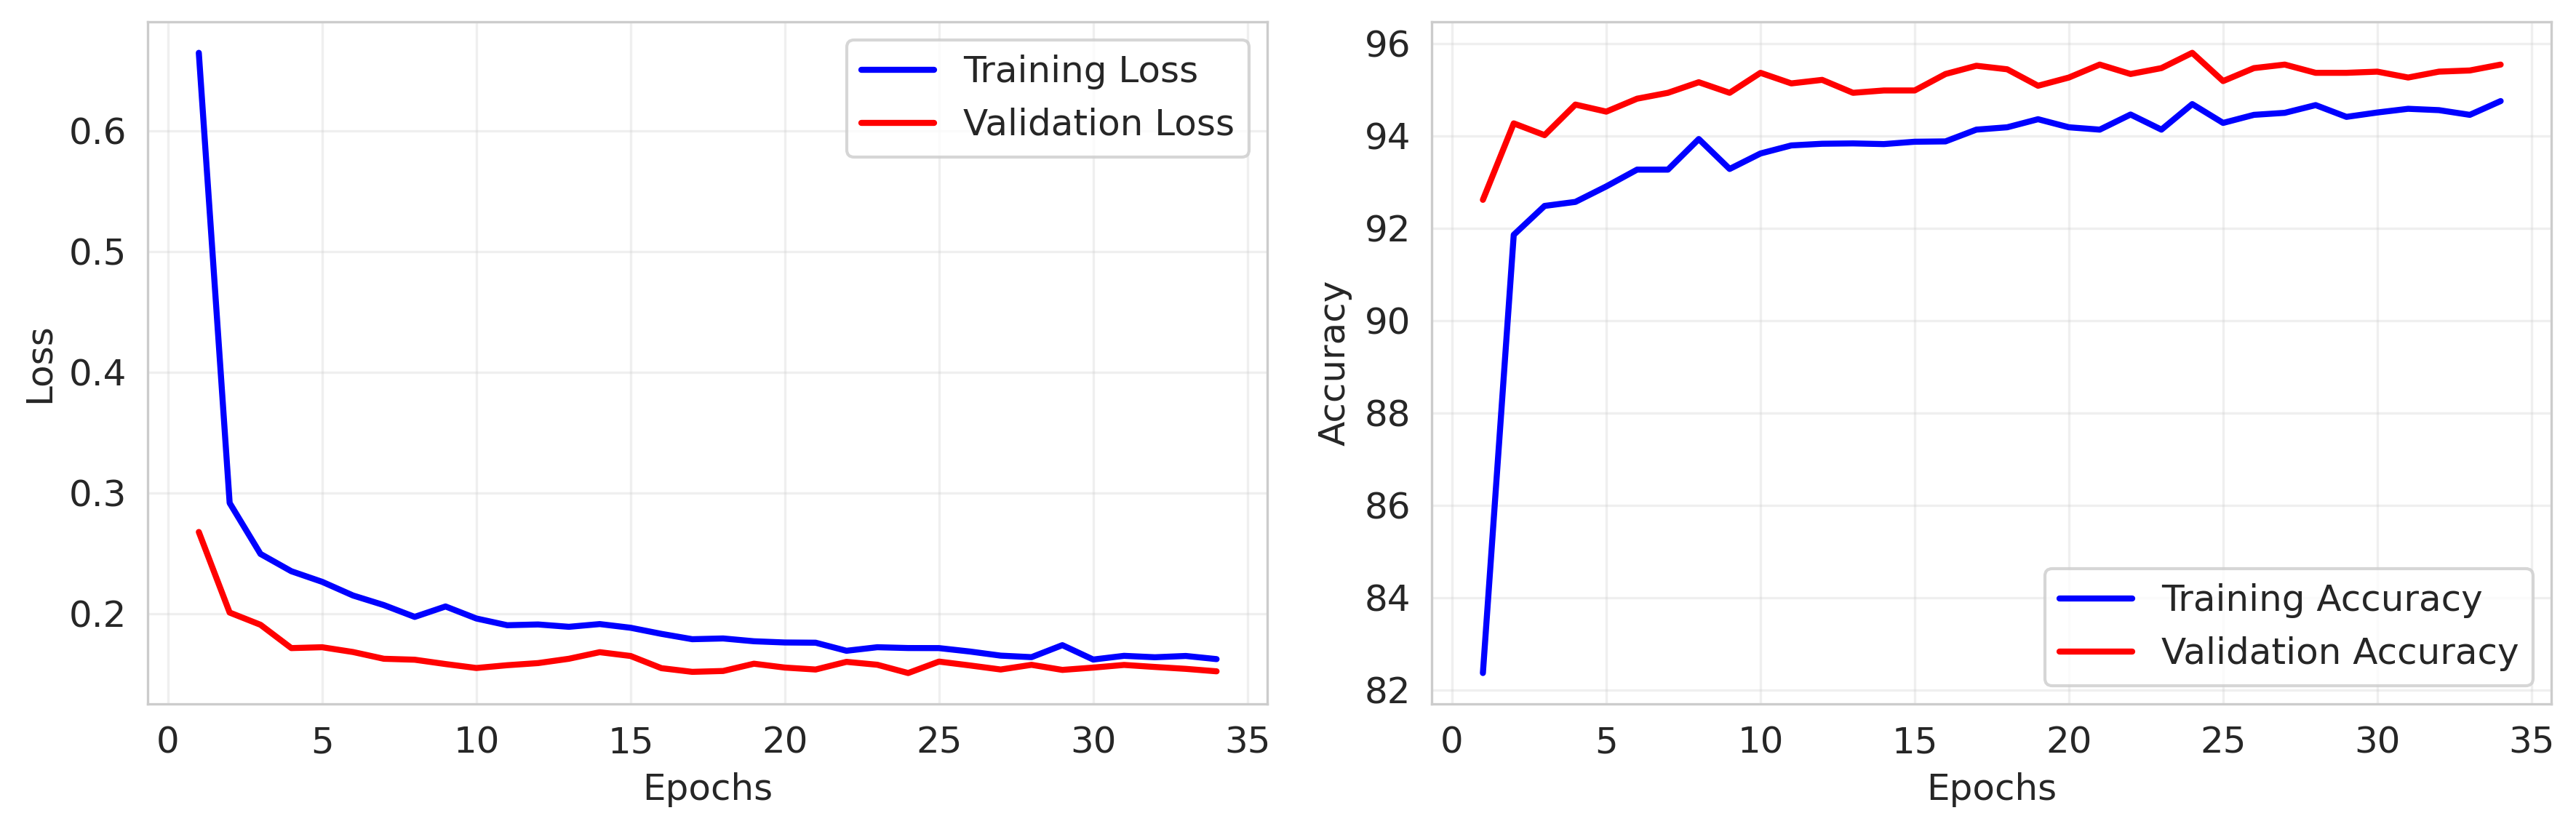


Learning curves of freeze mode all_but_fc and for fraction 100%


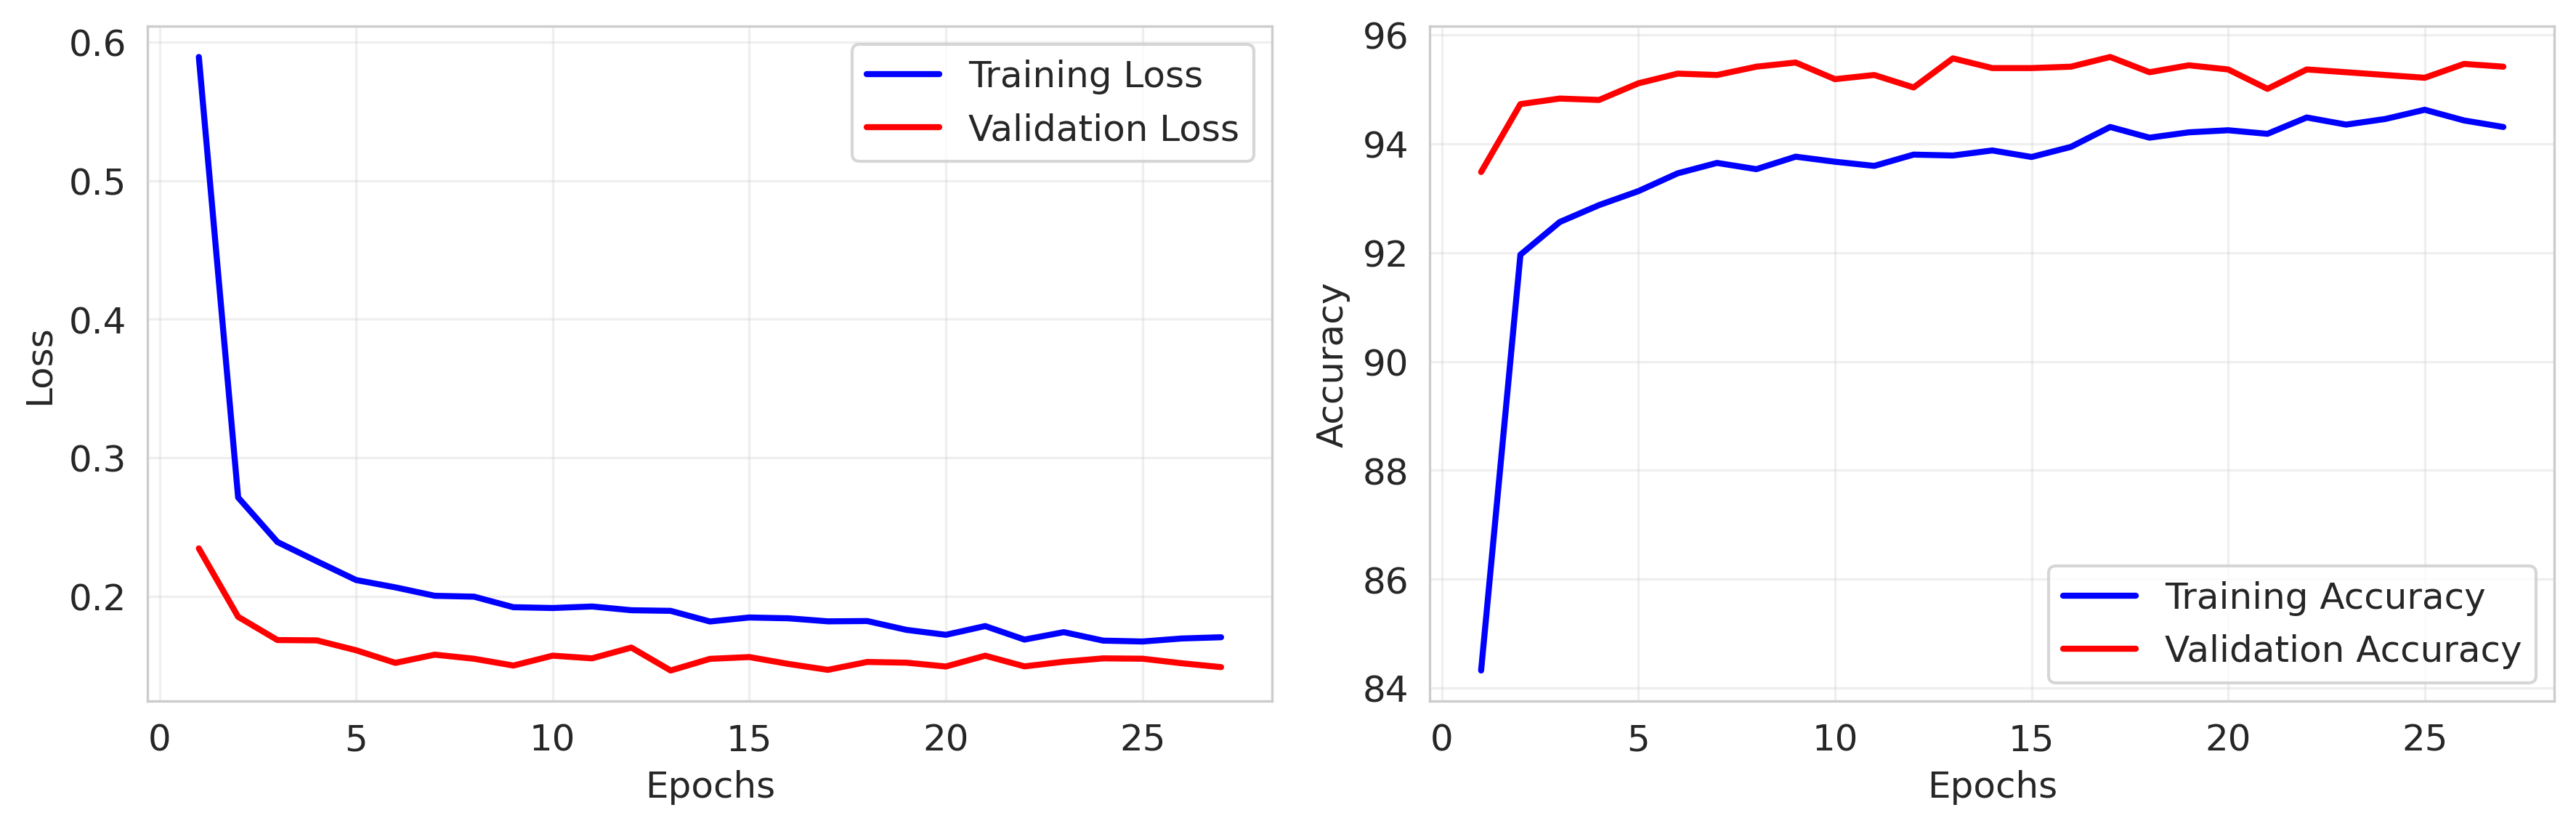


Learning curves of freeze mode up_to_layer1 and for fraction 10%


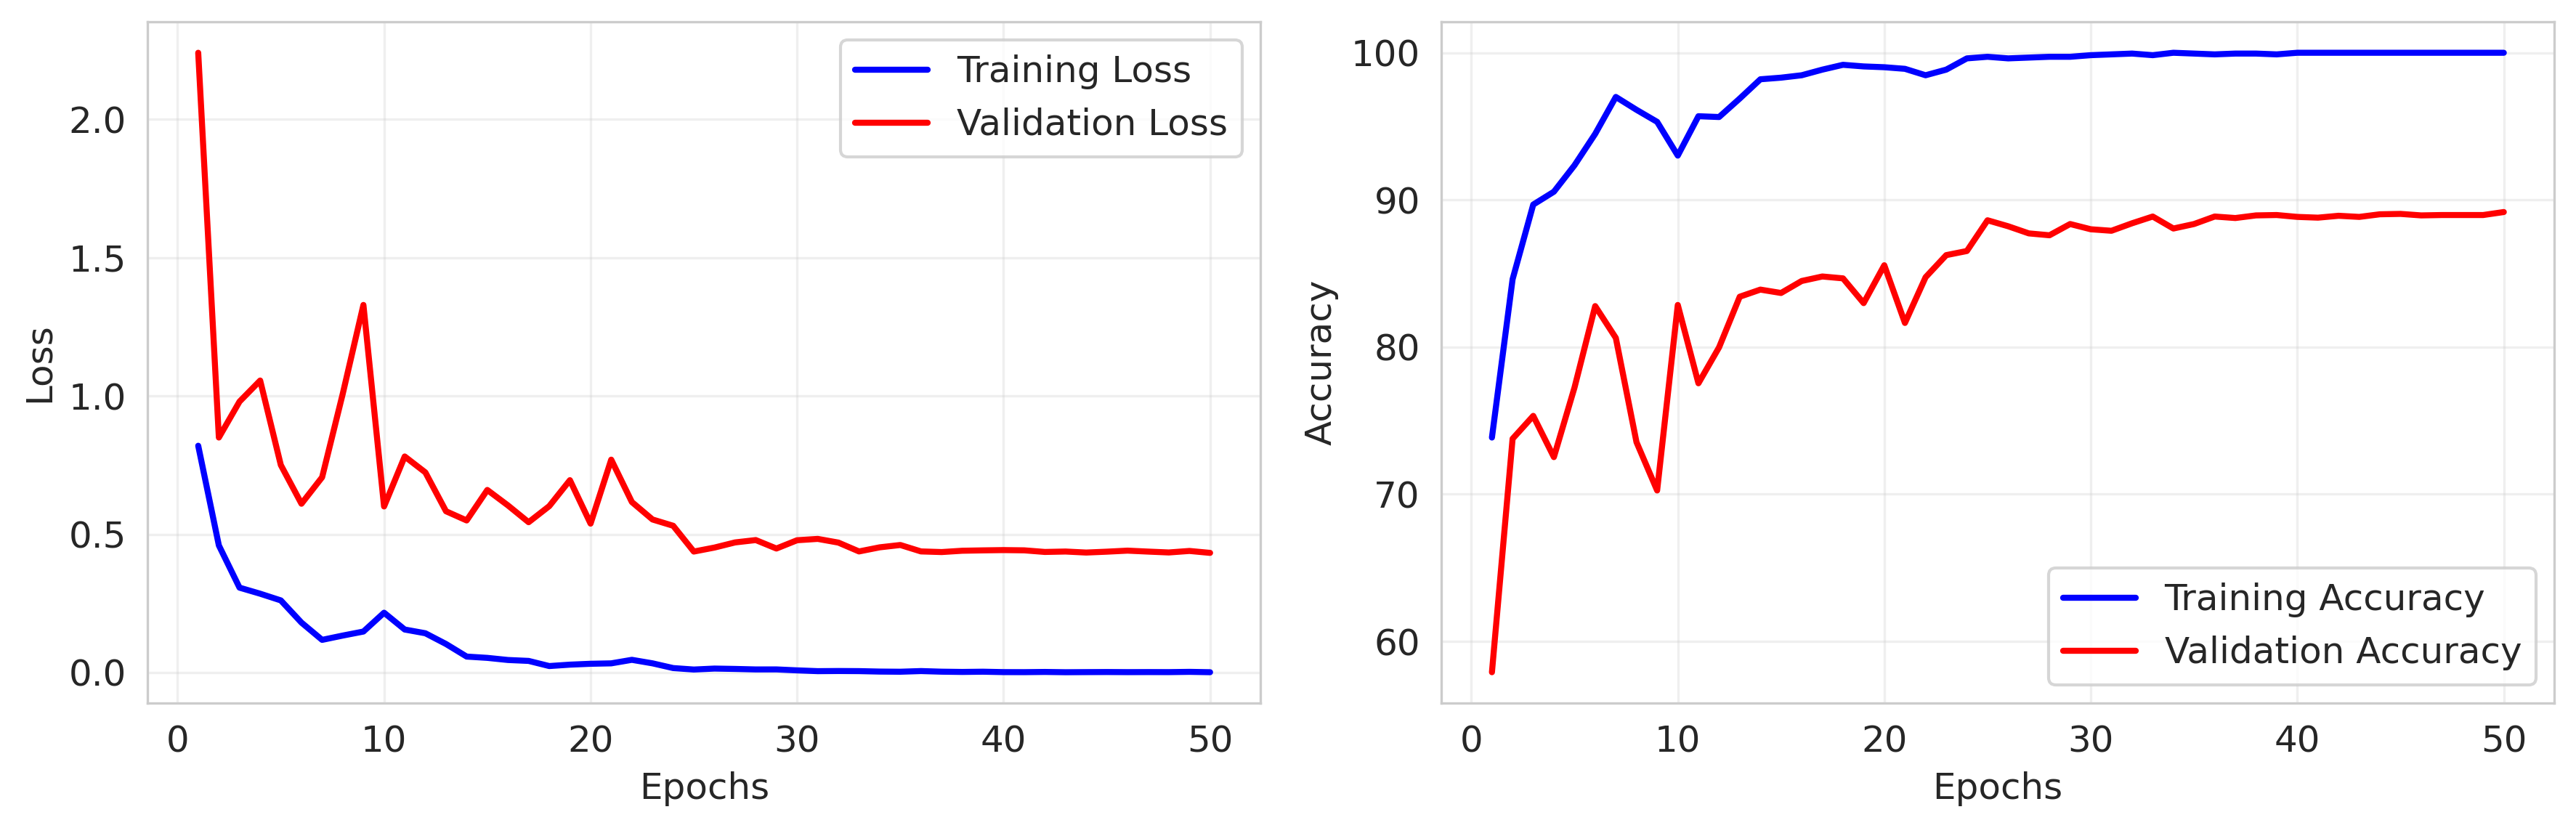


Learning curves of freeze mode up_to_layer1 and for fraction 25%


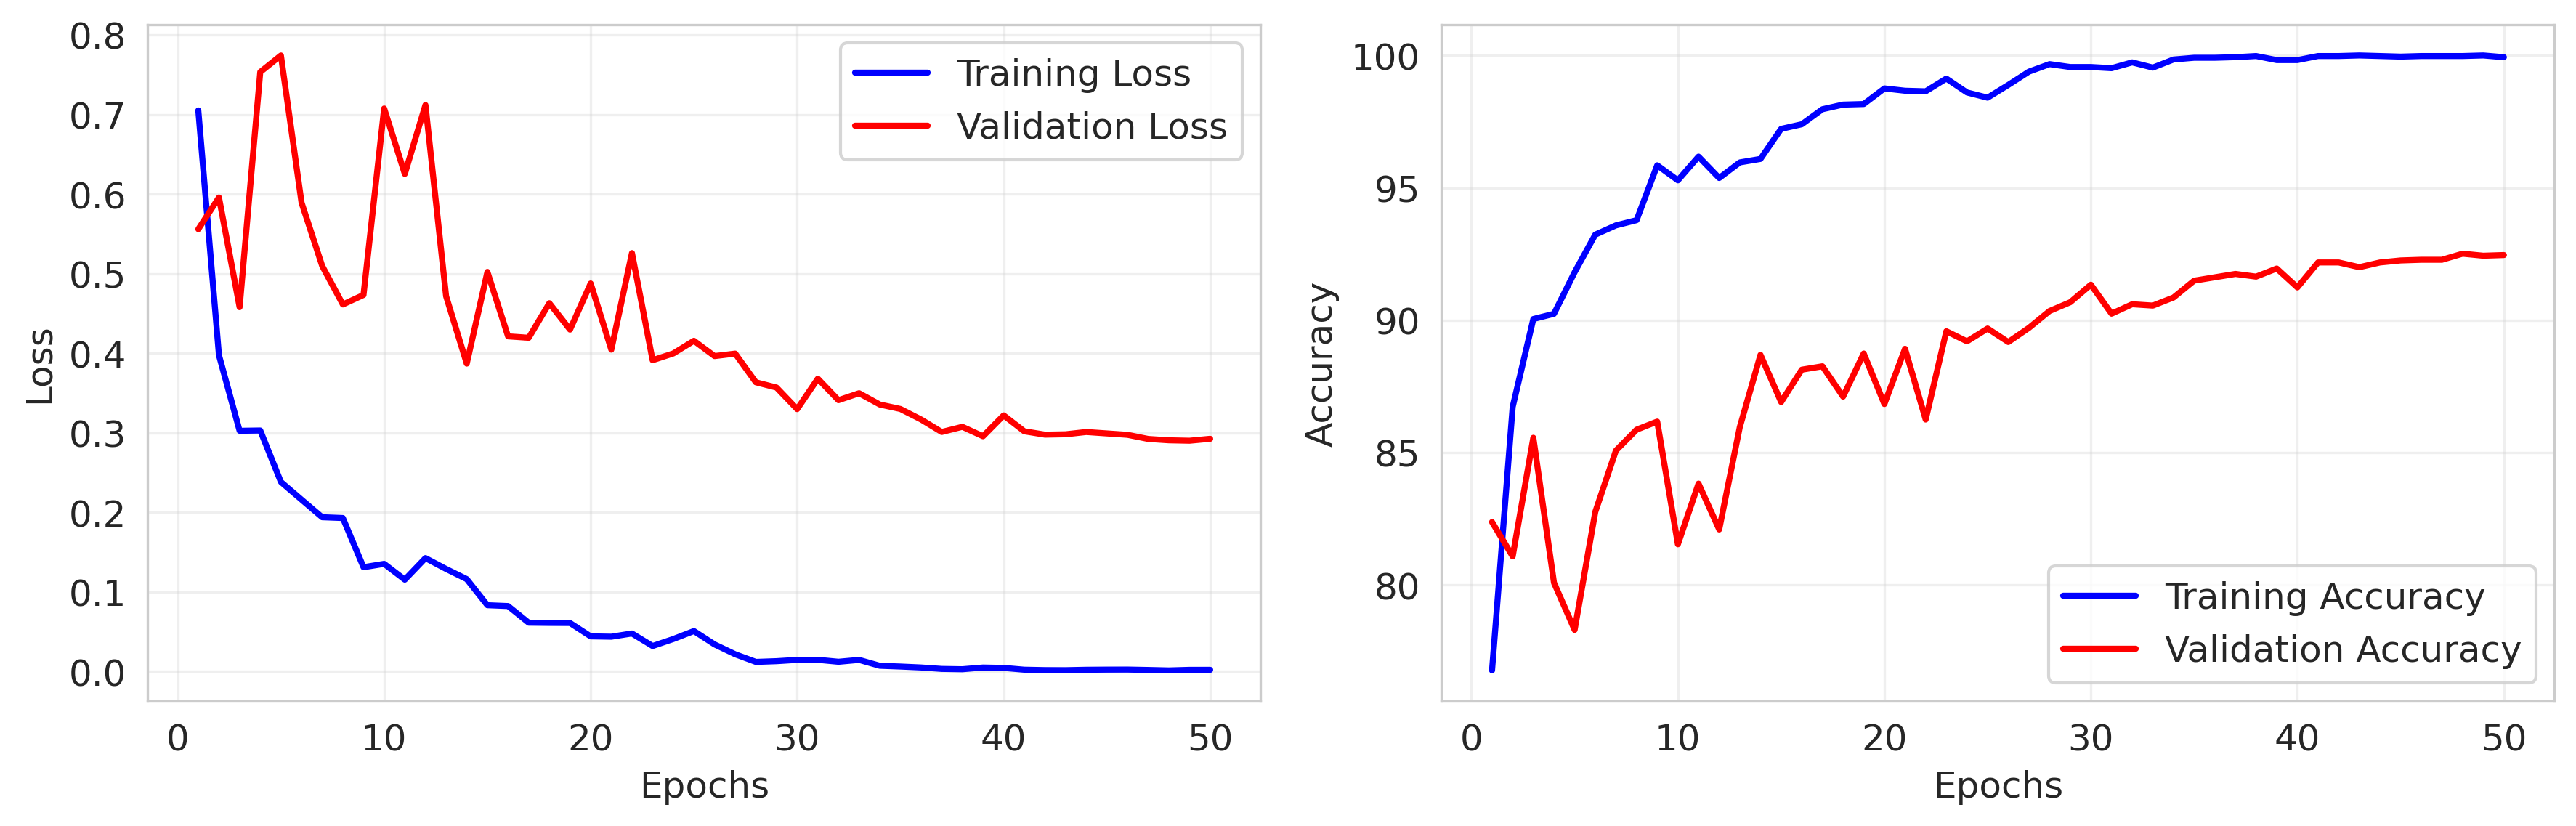


Learning curves of freeze mode up_to_layer1 and for fraction 50%


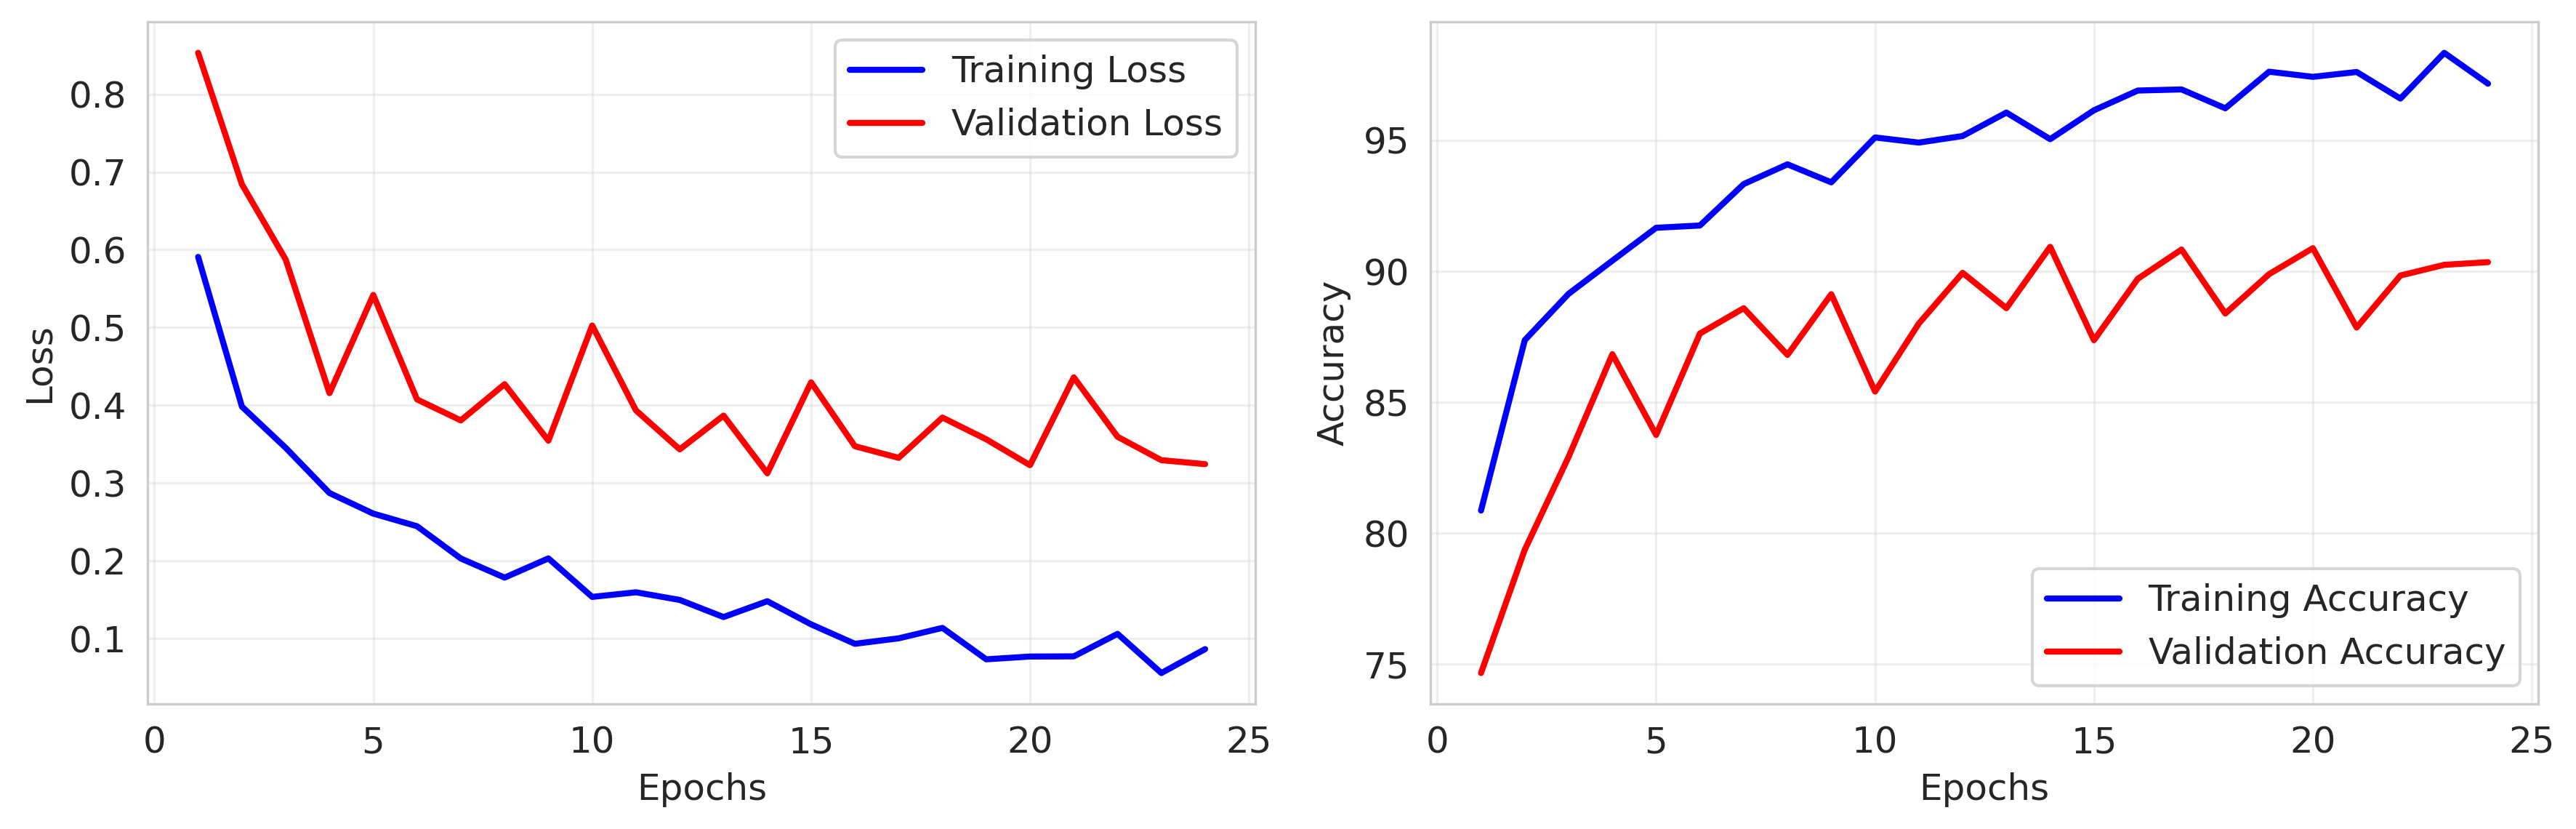


Learning curves of freeze mode up_to_layer1 and for fraction 75%


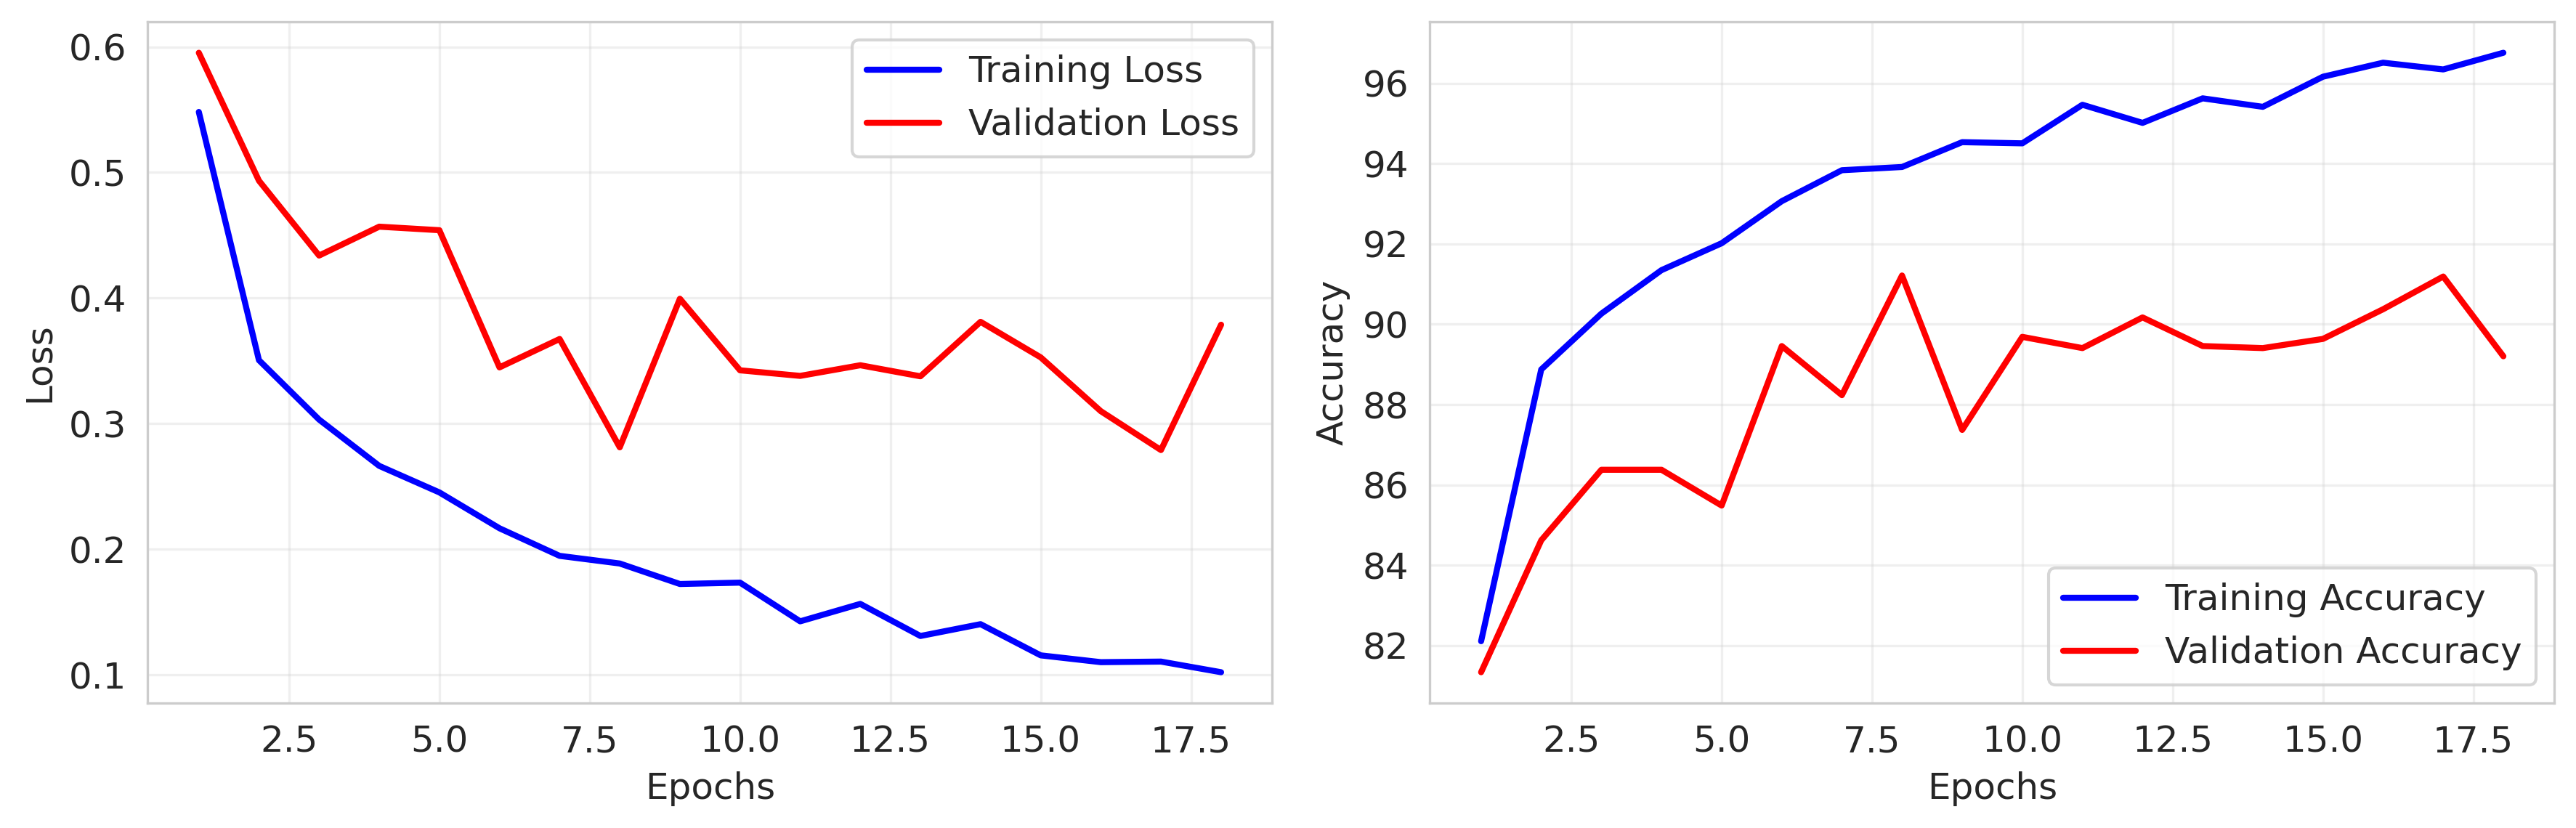


Learning curves of freeze mode up_to_layer1 and for fraction 100%


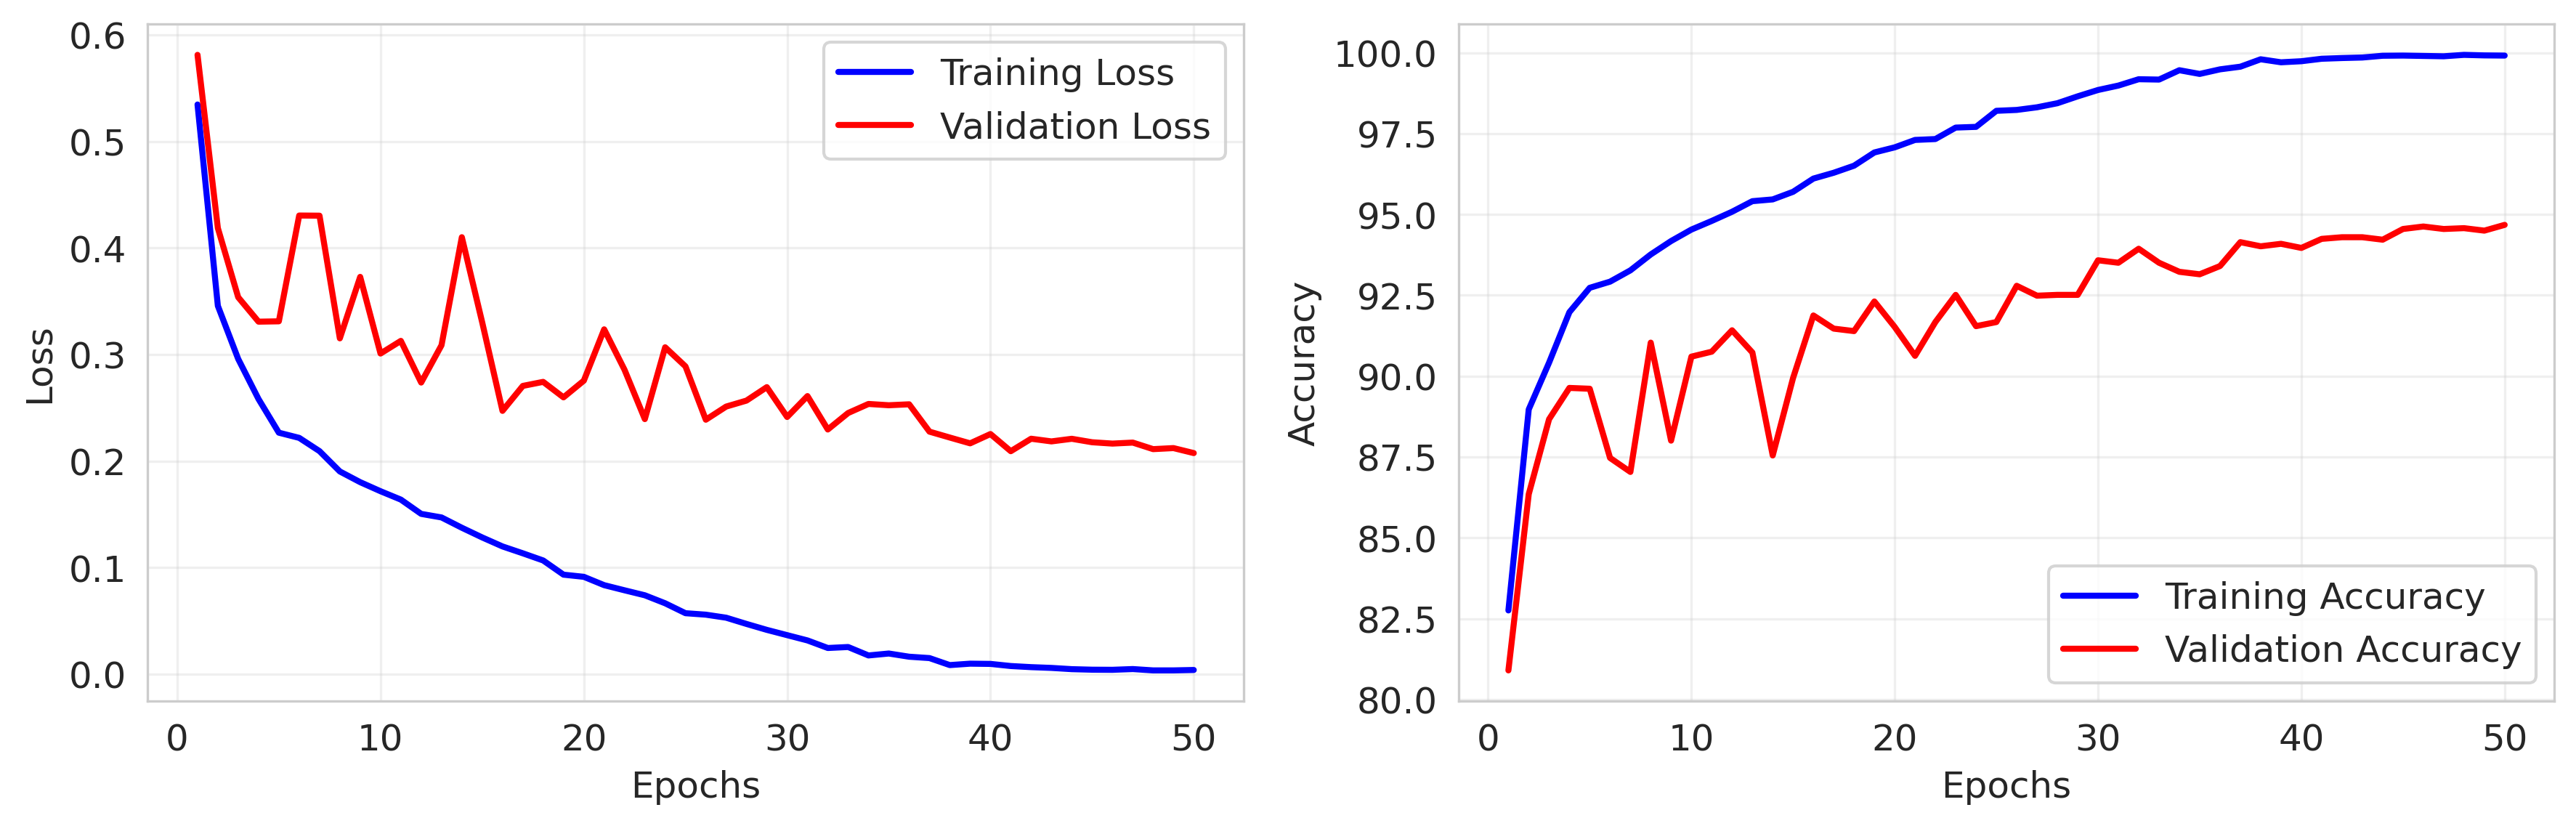


Learning curves of freeze mode up_to_layer2 and for fraction 10%


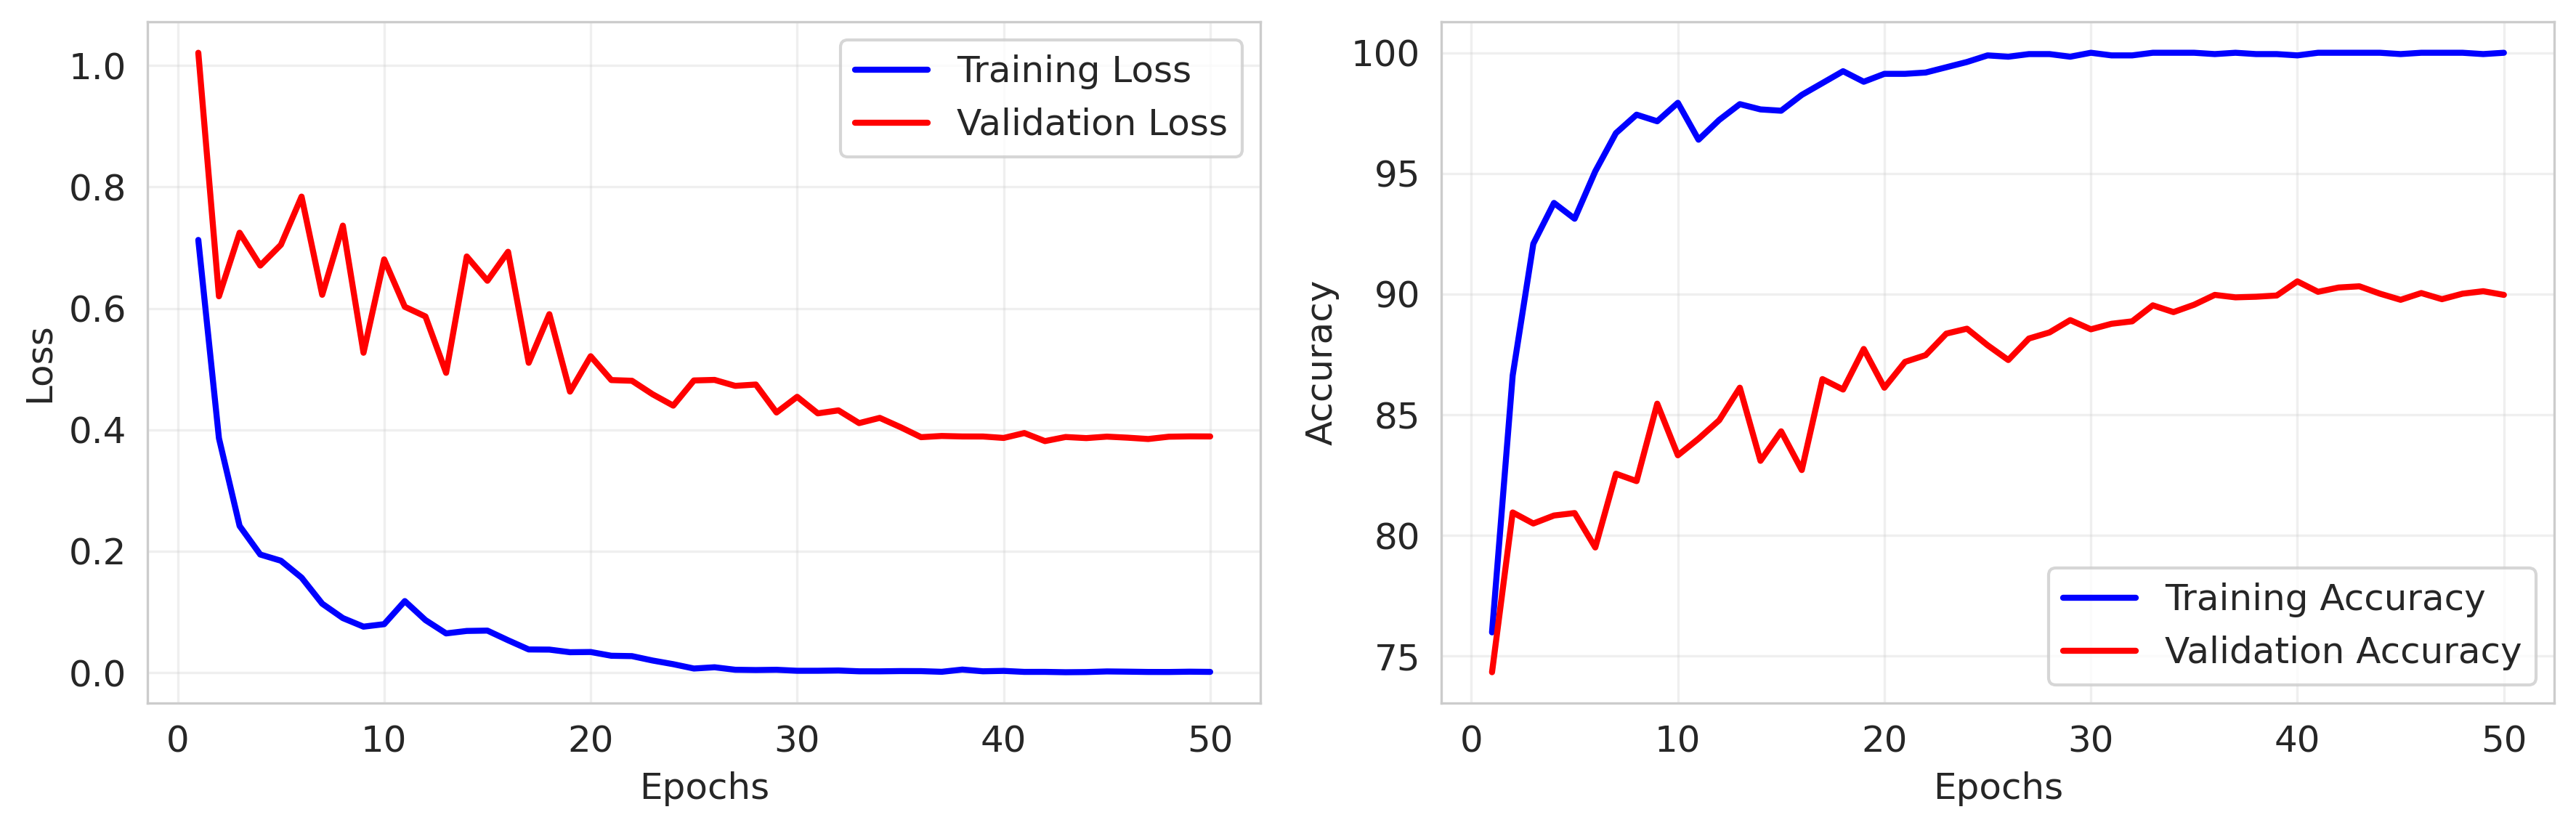


Learning curves of freeze mode up_to_layer2 and for fraction 25%


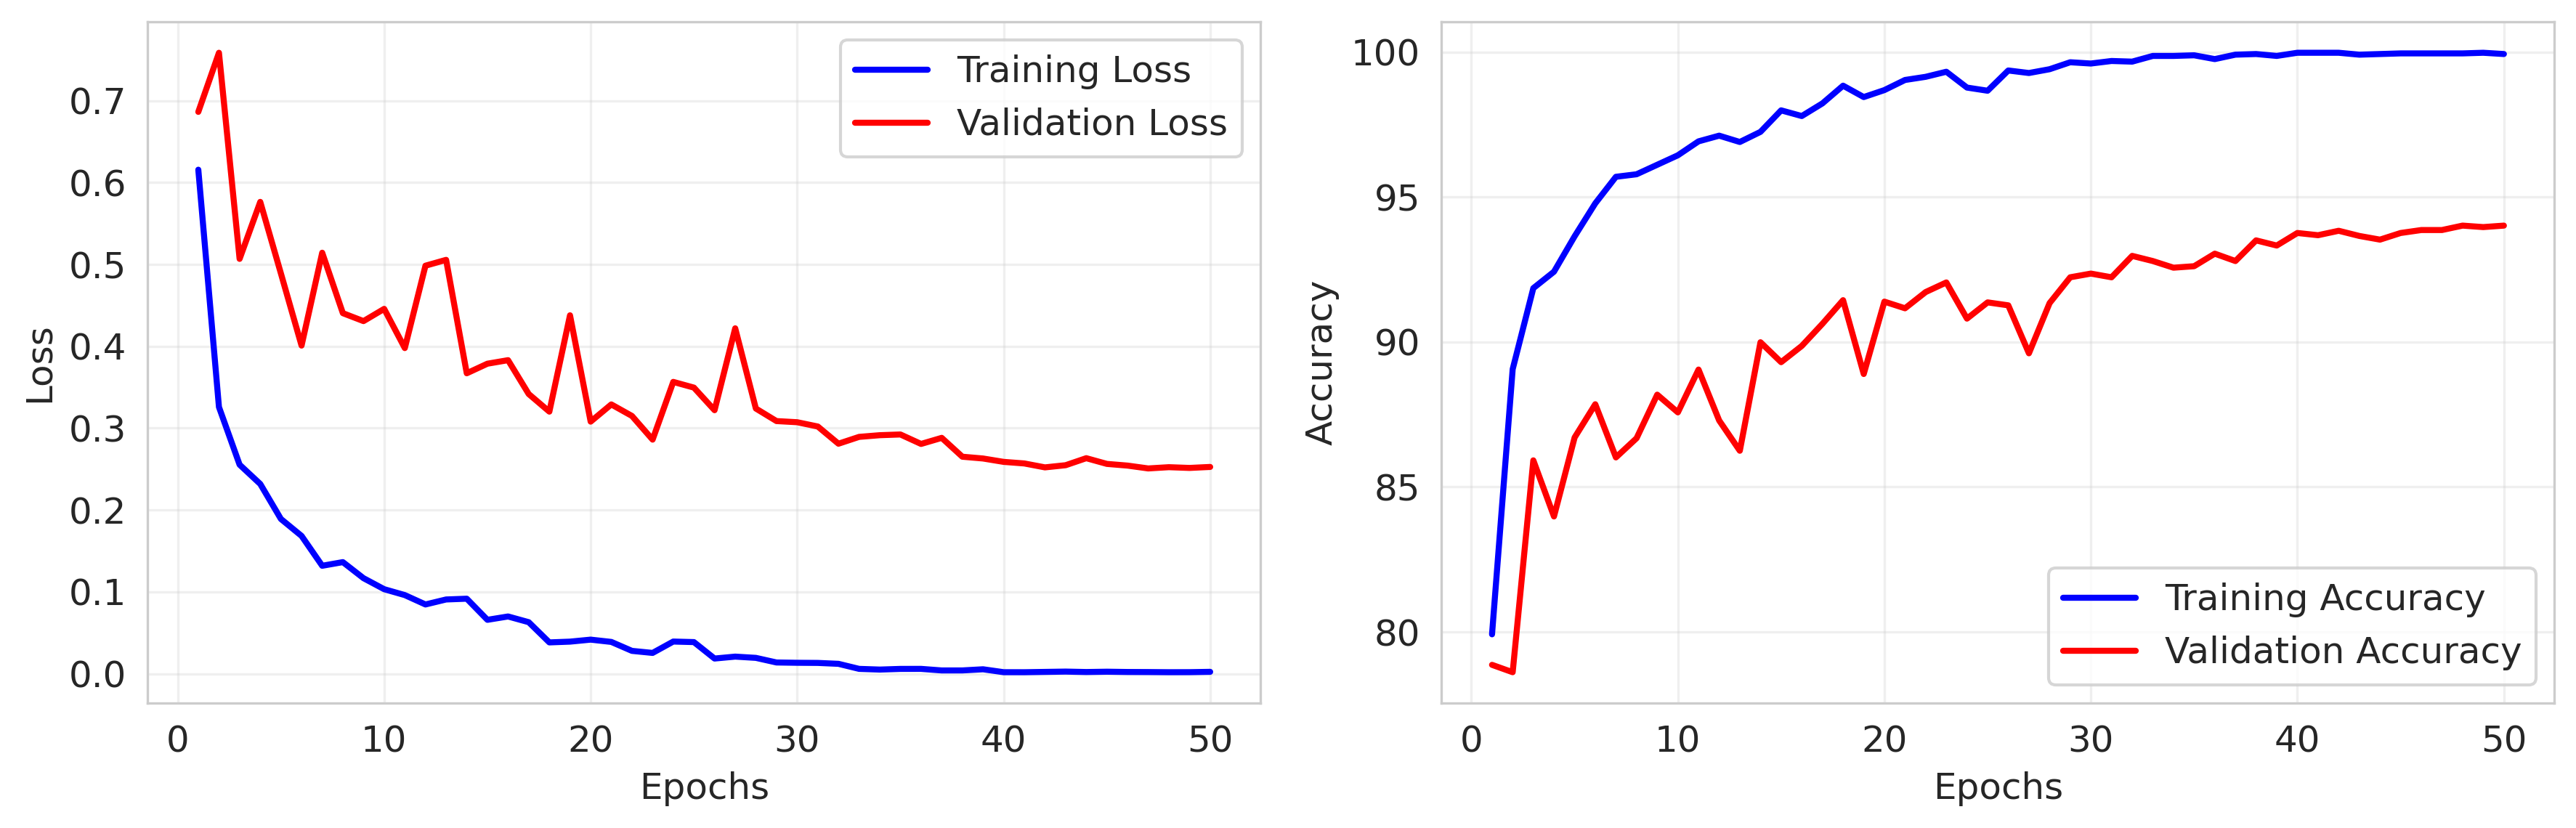


Learning curves of freeze mode up_to_layer2 and for fraction 50%


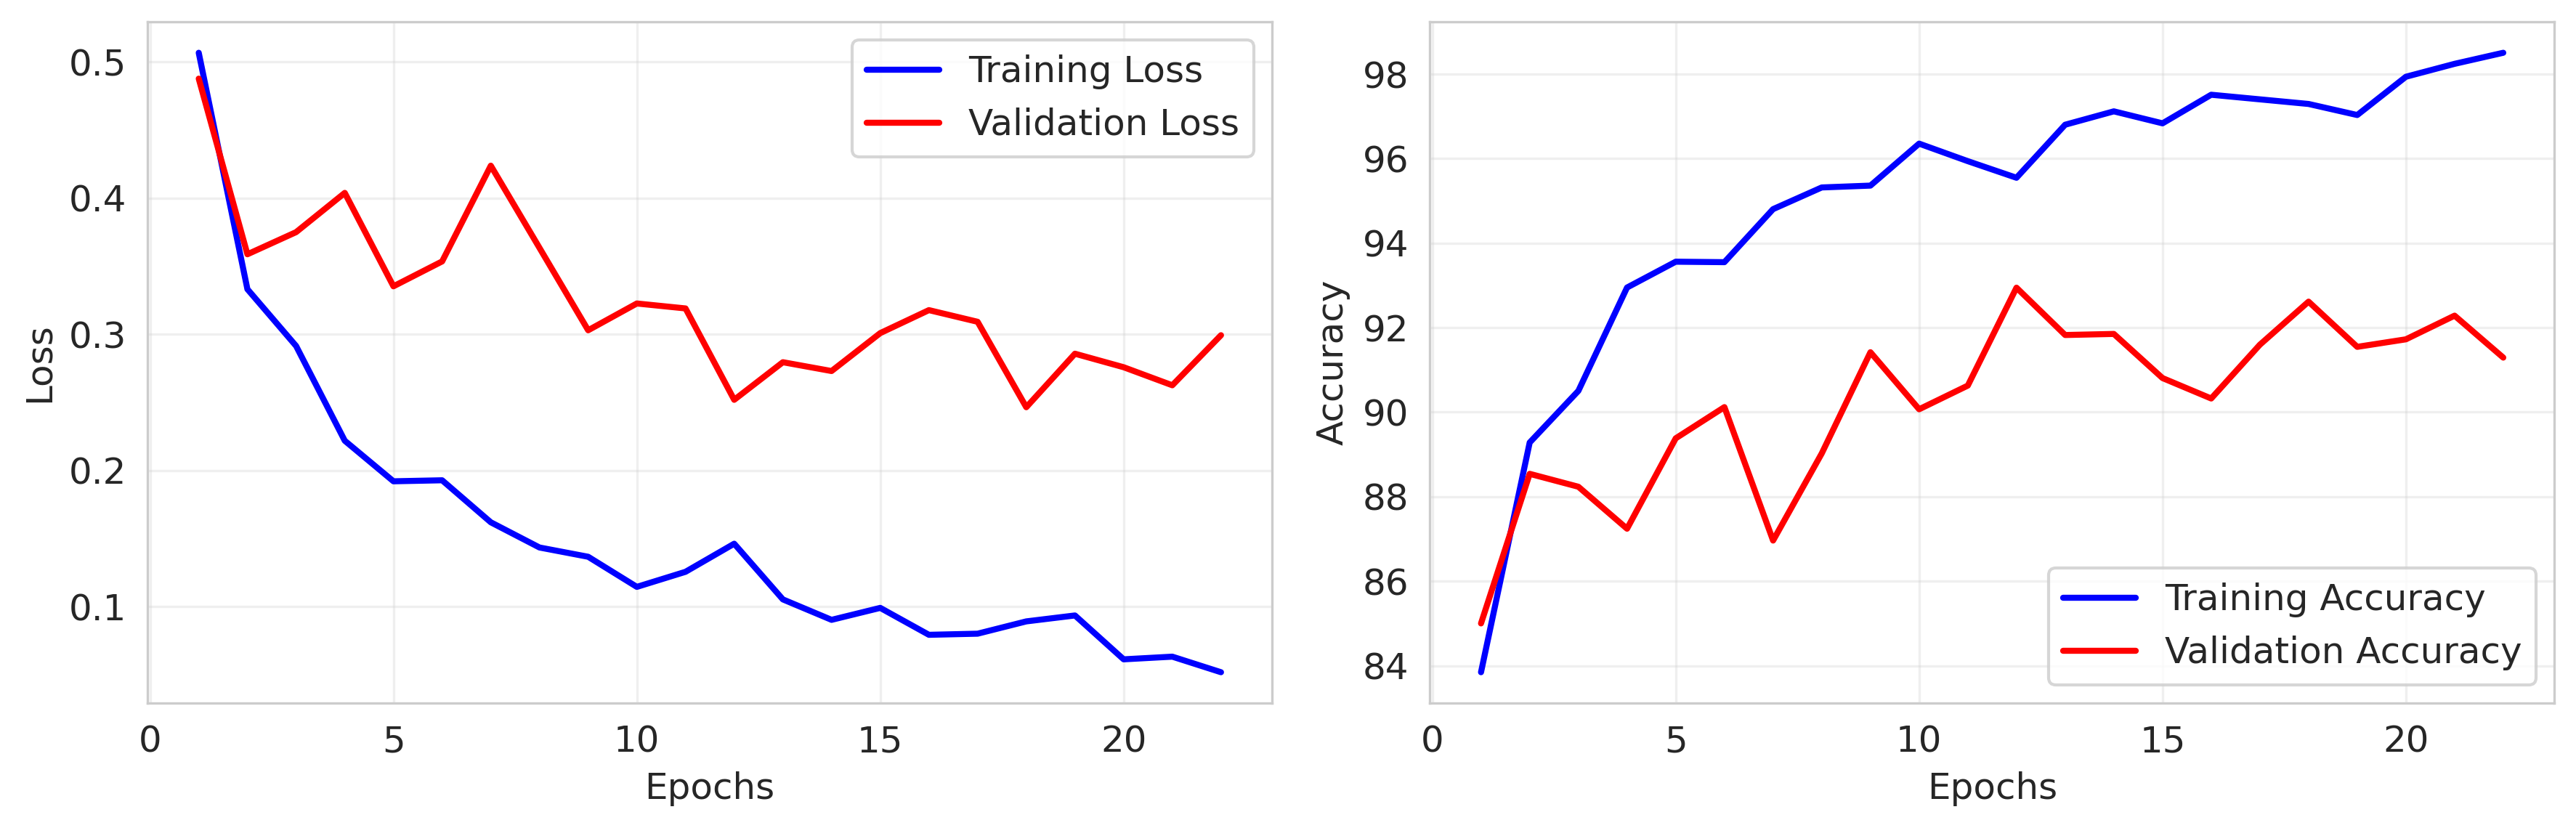


Learning curves of freeze mode up_to_layer2 and for fraction 75%


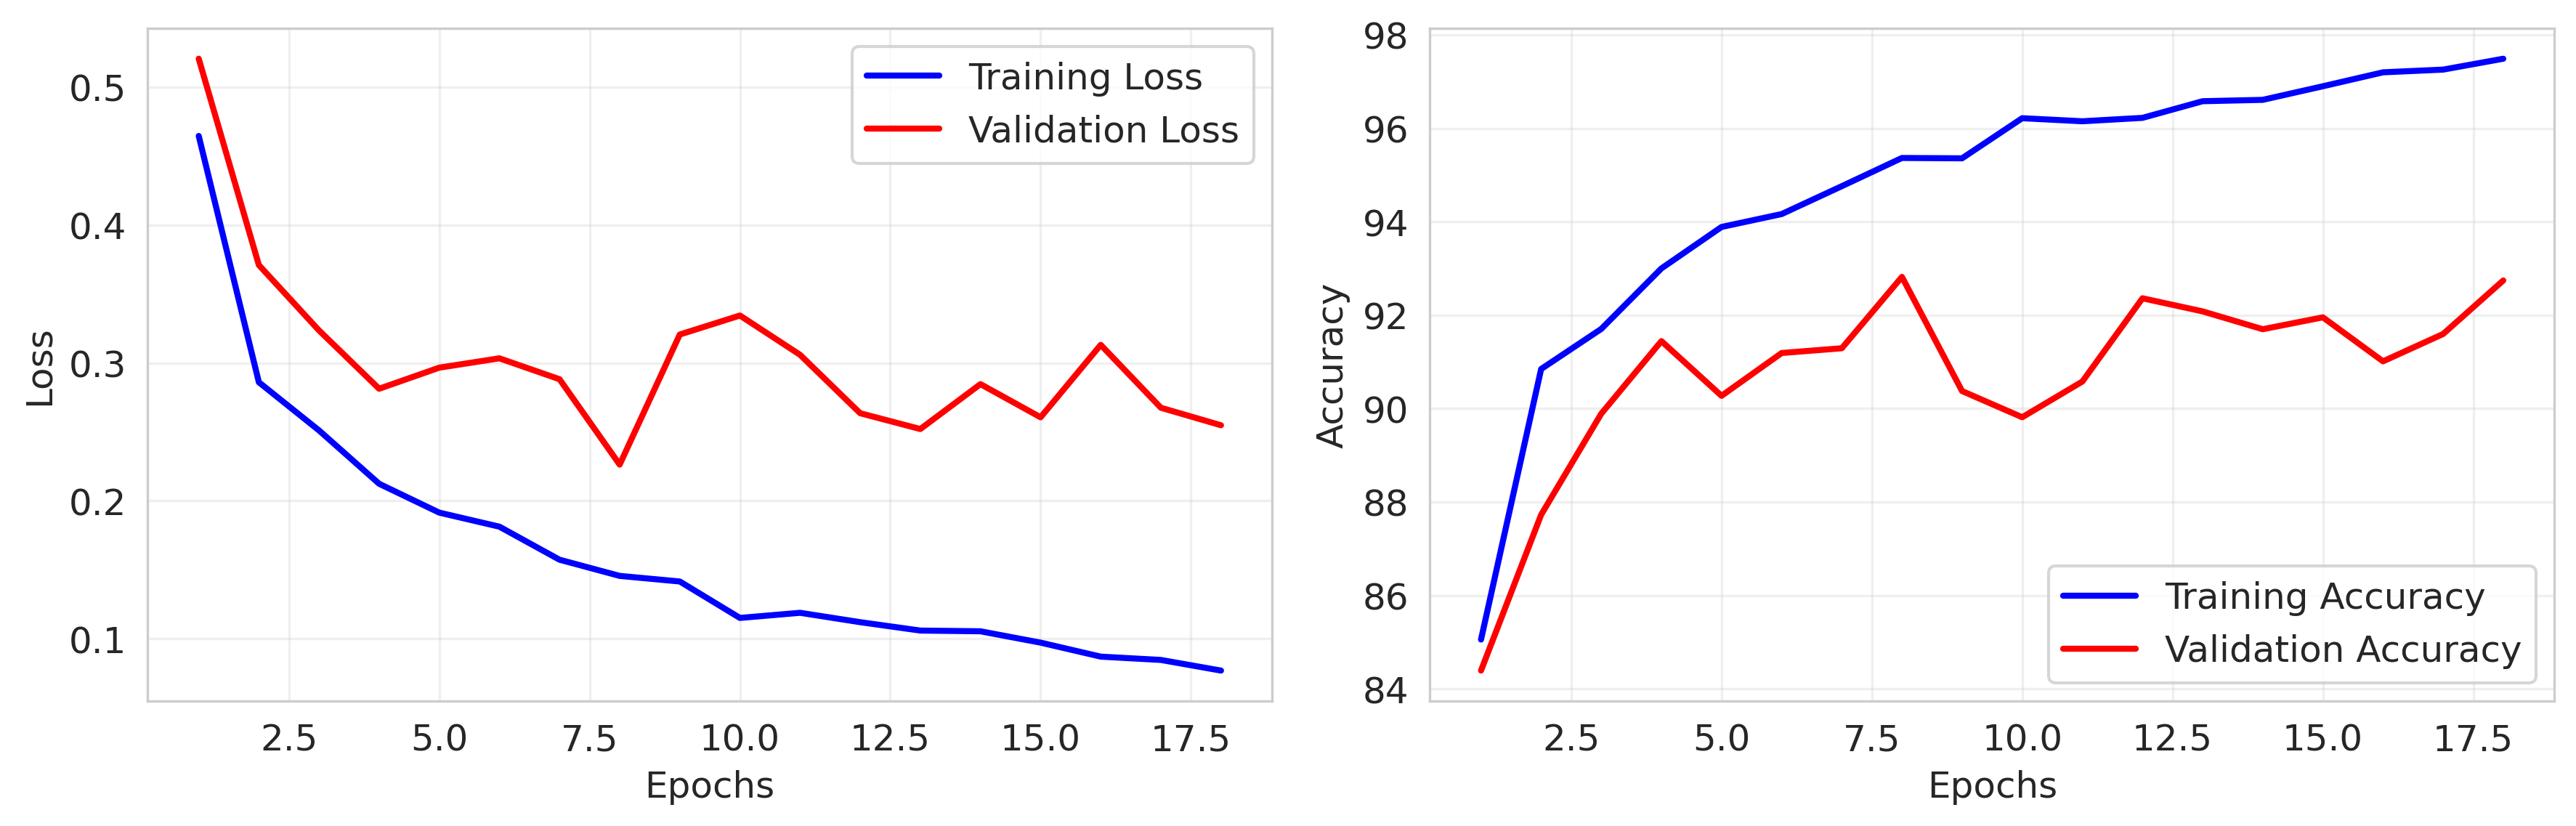


Learning curves of freeze mode up_to_layer2 and for fraction 100%


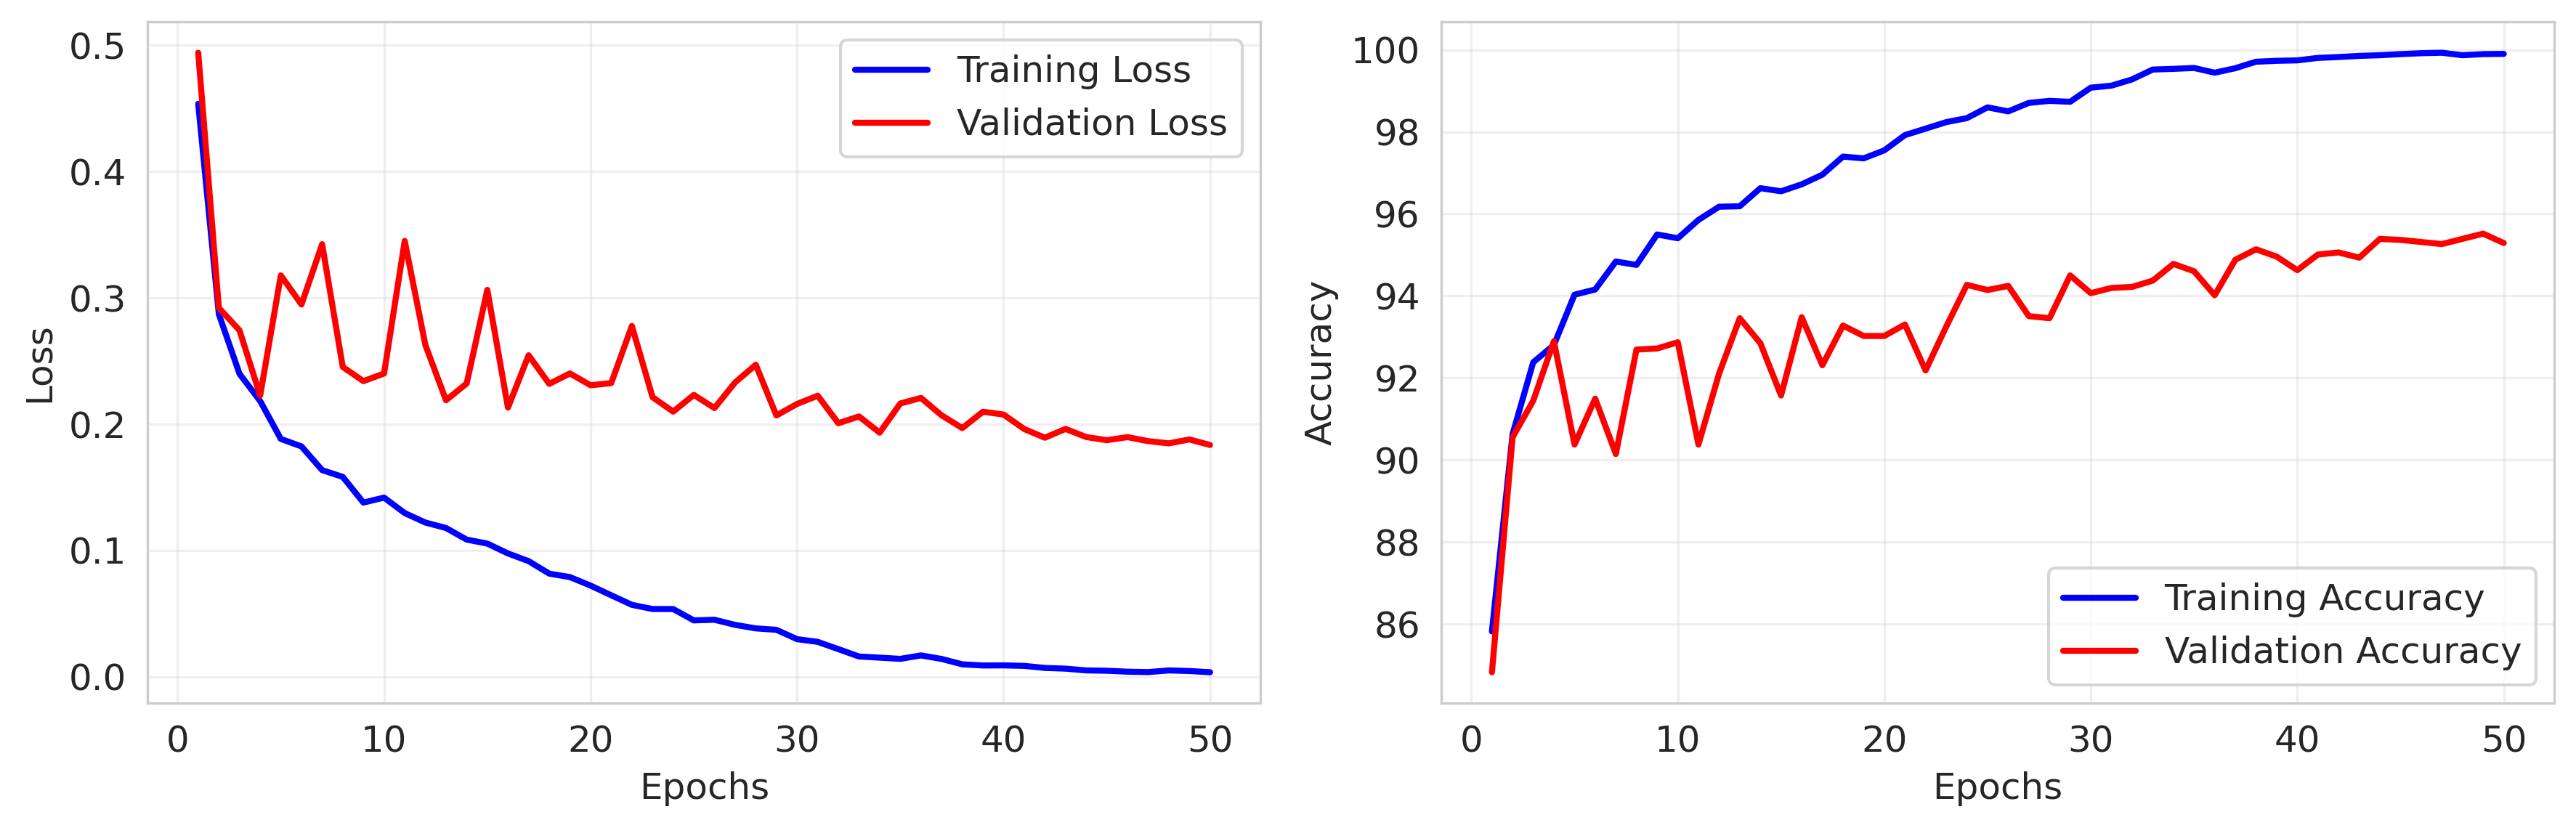


Learning curves of freeze mode up_to_layer3 and for fraction 10%


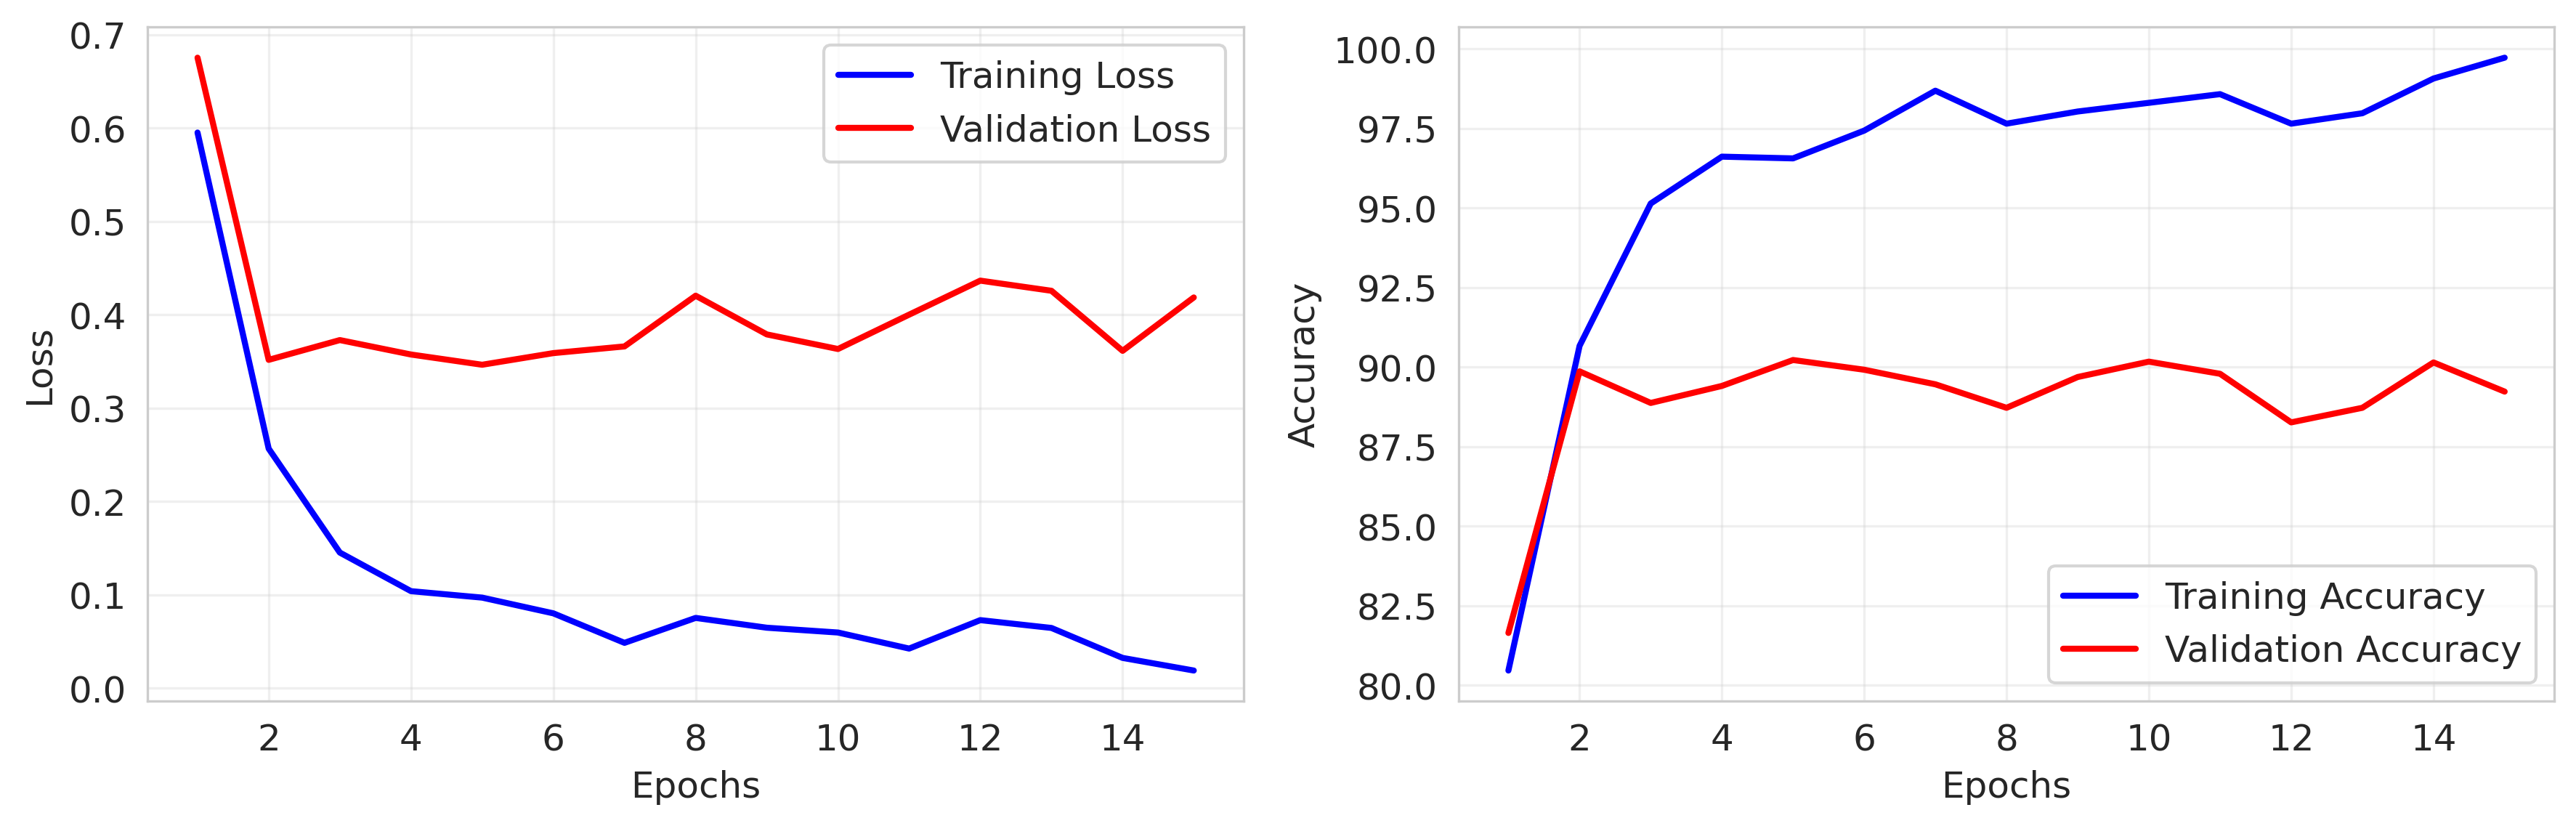


Learning curves of freeze mode up_to_layer3 and for fraction 25%


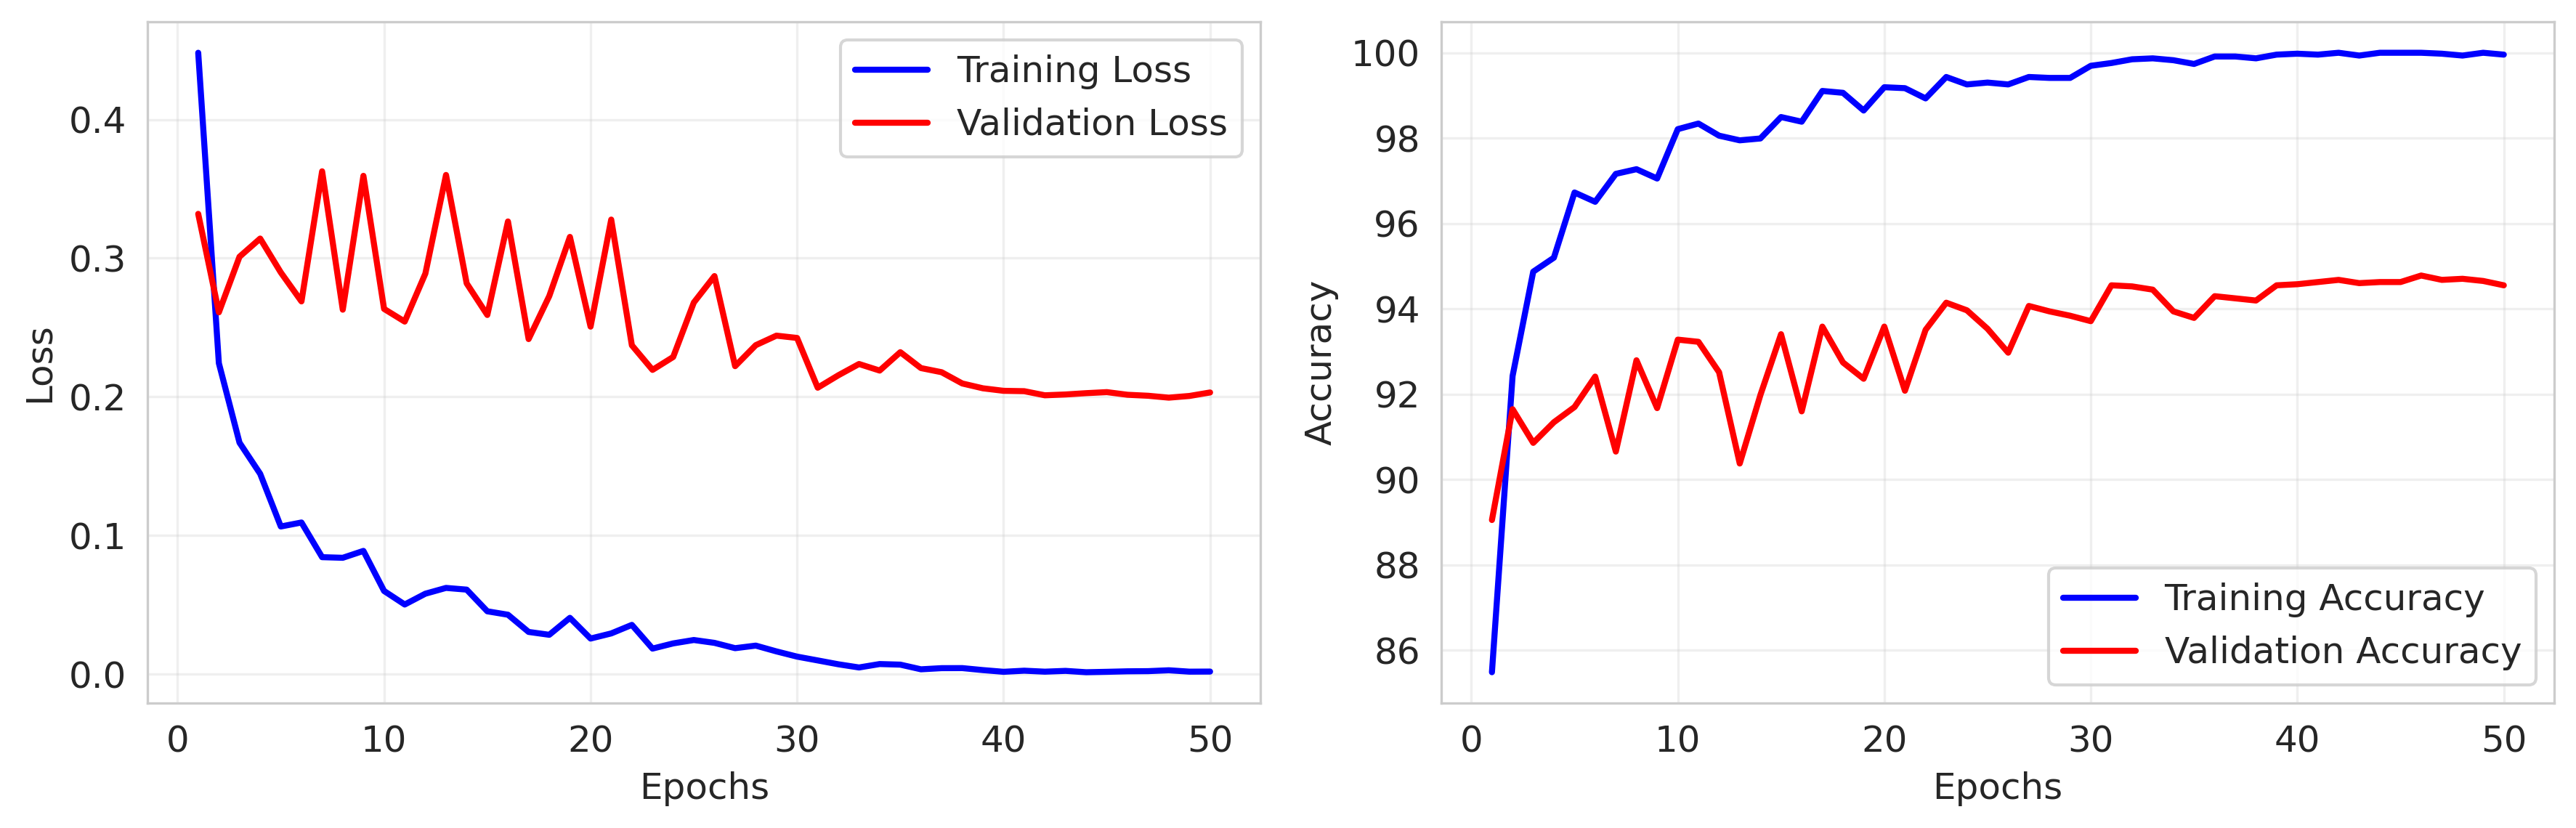


Learning curves of freeze mode up_to_layer3 and for fraction 50%


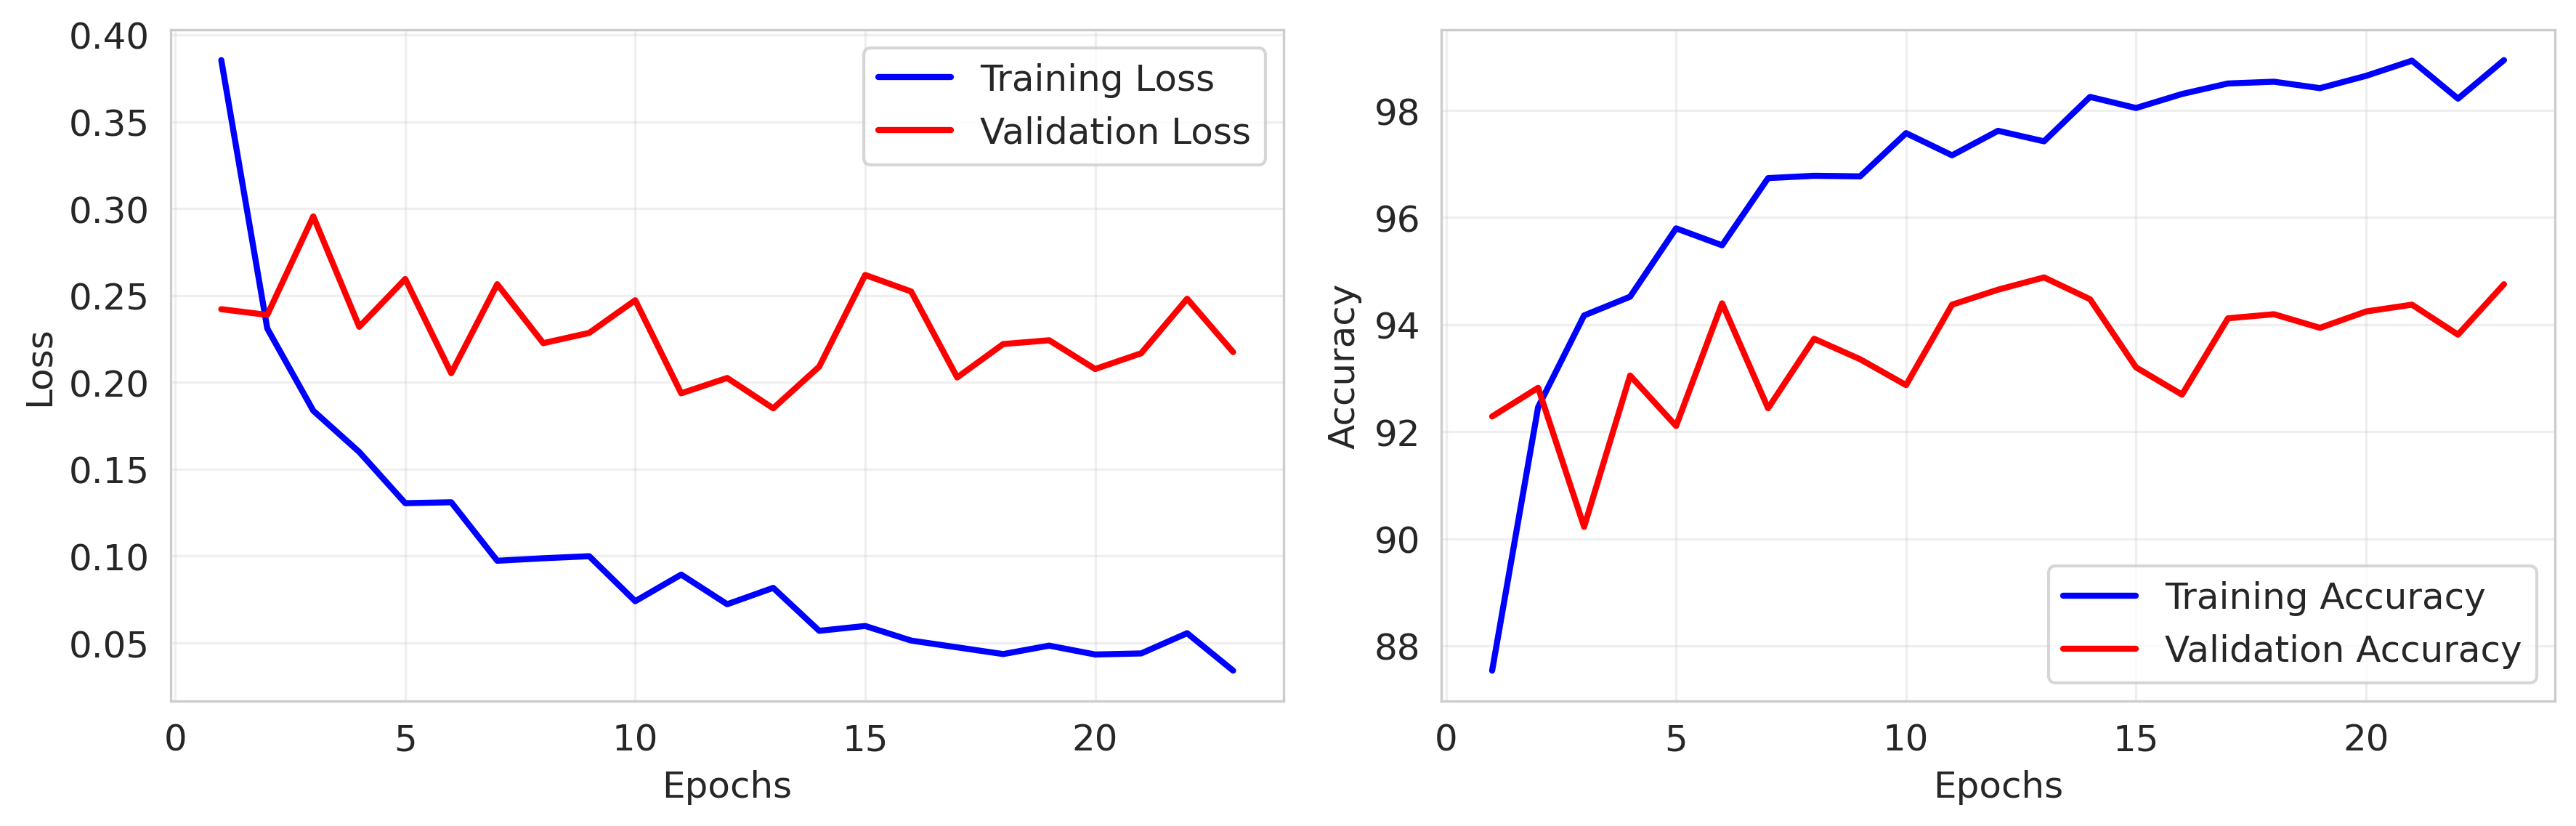


Learning curves of freeze mode up_to_layer3 and for fraction 75%


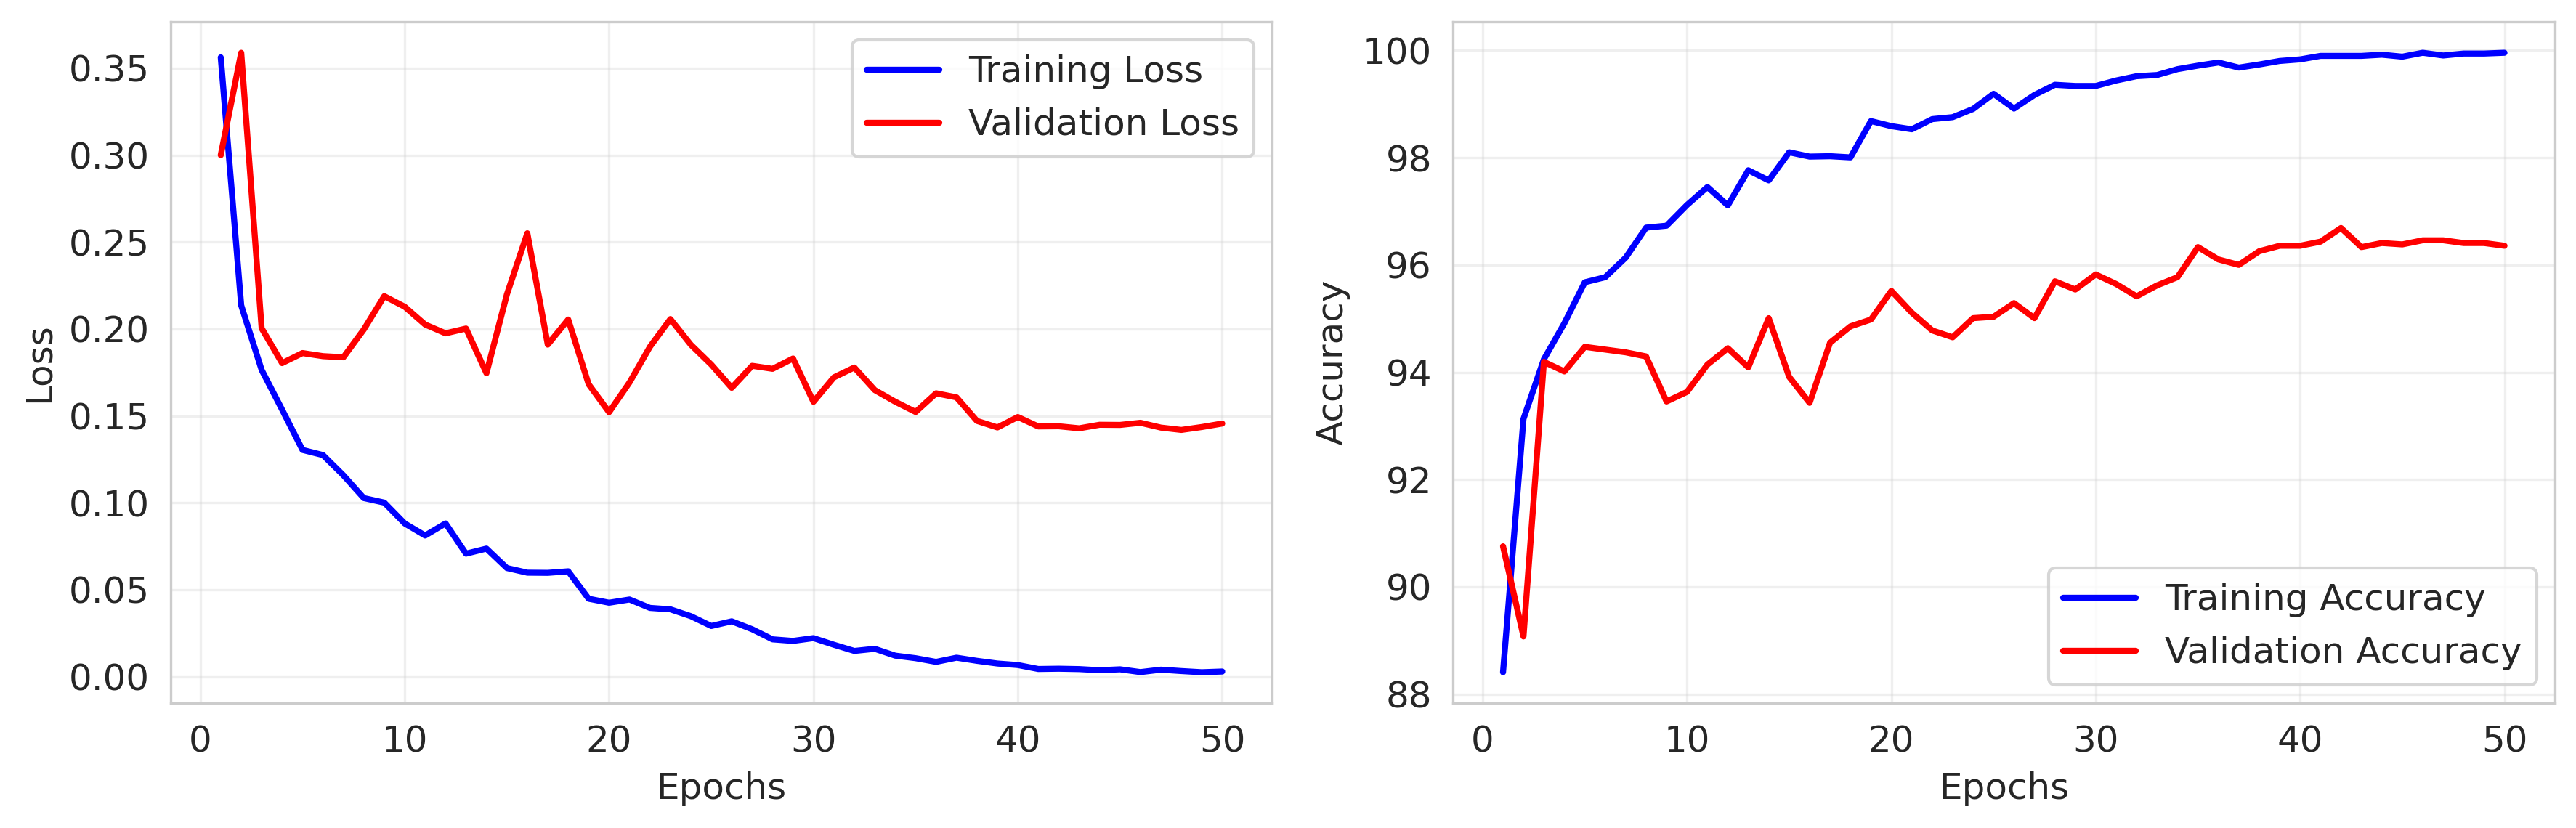


Learning curves of freeze mode up_to_layer3 and for fraction 100%


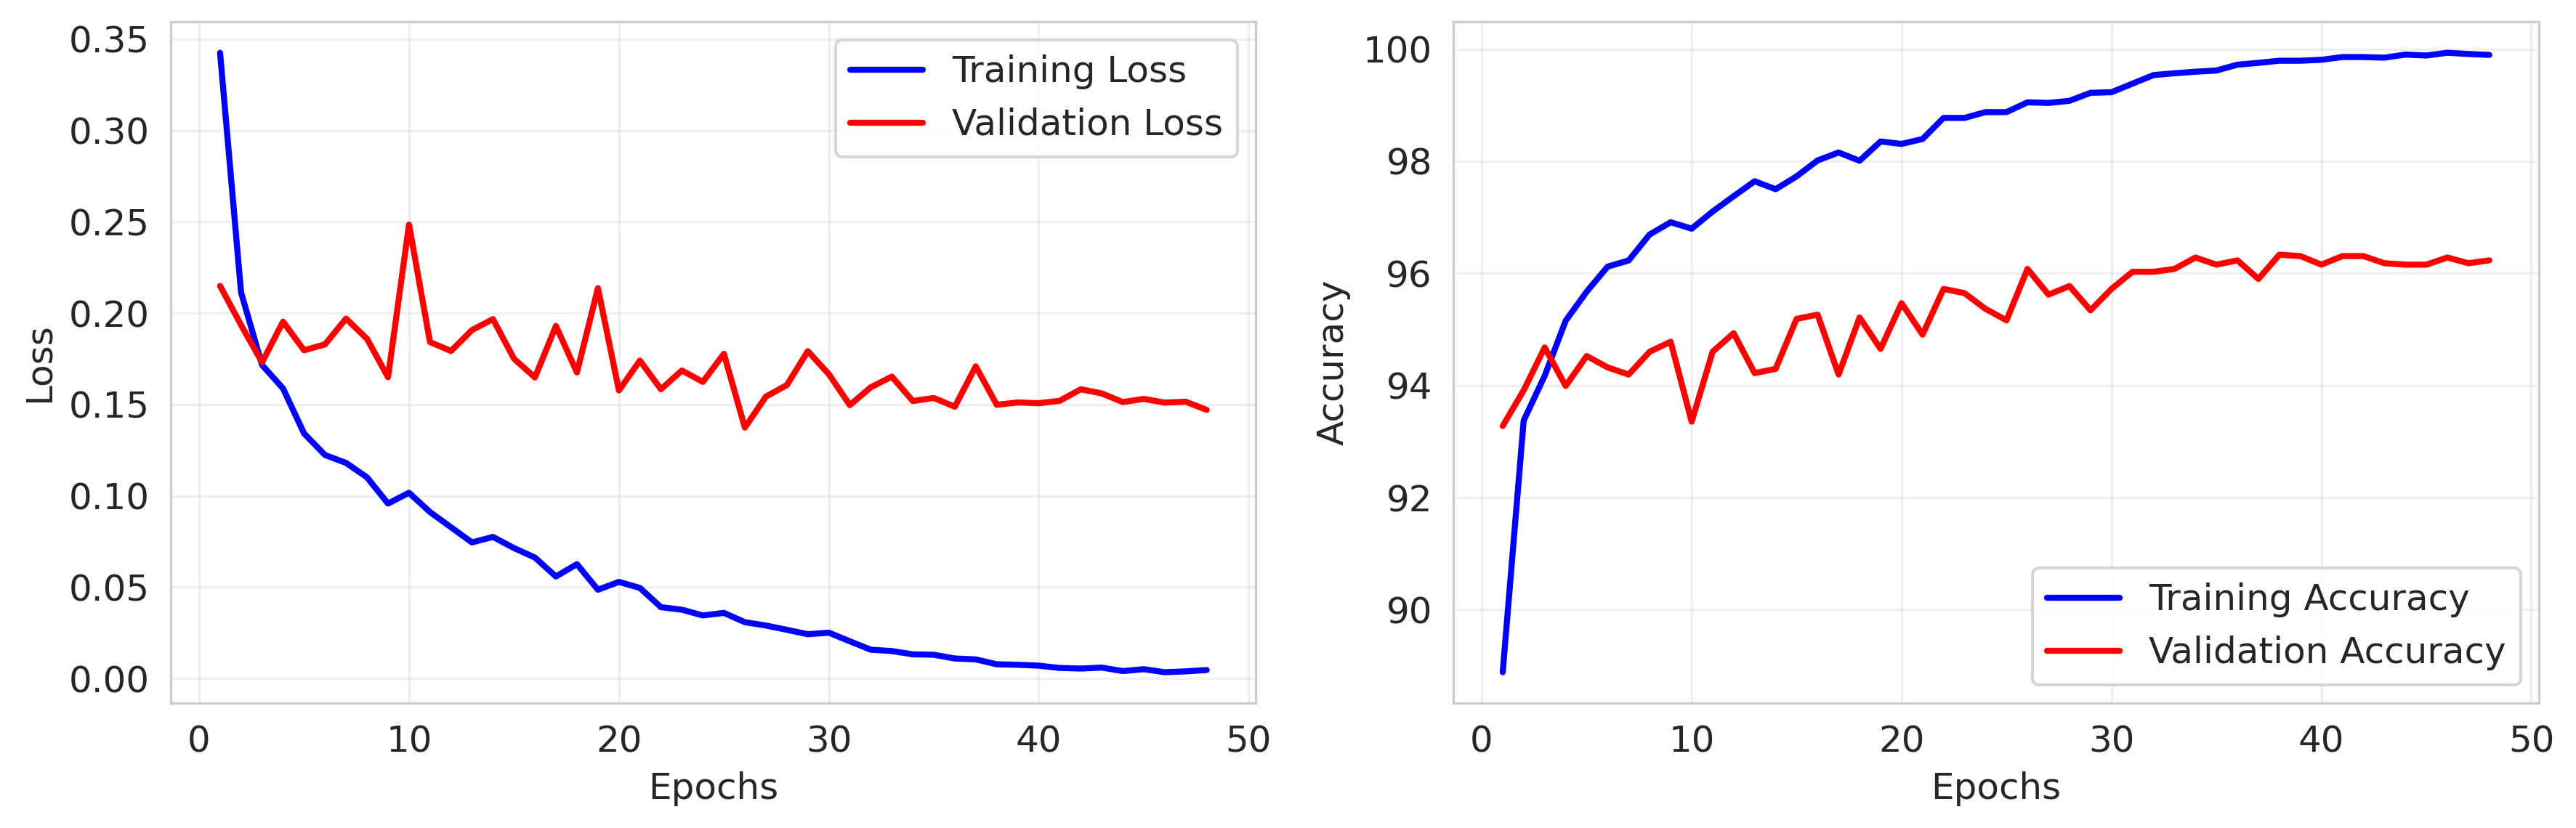

In [ ]:
from IPython.display import Image, display

for freeze_mode in freeze_modes:
  for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task2_fine_tuned_{freeze_mode}_{frac:.2f}.png"
    if plot_path.exists():
        print(f"\nLearning curves of freeze mode {freeze_mode} and for fraction {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

In [ ]:
!zip -r results_task2.zip /content/TOL506M_Final_Project/results/

updating: content/TOL506M_Final_Project/results/ (stored 0%)
updating: content/TOL506M_Final_Project/results/plots/ (stored 0%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.75.png (deflated 11%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_all_but_fc_0.75.png (deflated 14%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.50.png (deflated 10%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.10.png (deflated 12%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.75.png (deflated 10%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.25.png (deflated 10%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.50.png (deflated 10%)
updating: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.10.png (deflated 12%)
updating: 

In [ ]:
from google.colab import files
files.download("results_task2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>